In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import pandas as pd
import os

# ignore warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Load data
# Get the data directory located one level up from the current working directory
data_dir = os.path.join(os.path.dirname(os.getcwd()), 'data')

# Load the real issa spectra data from CSV files
issa_data = pd.read_excel(os.path.join(data_dir, 'ISSA_17_Jan_2025_Yan_Lu.xlsx'), sheet_name='ISSA')
site_names = {1: 'Back of Hand', 2: 'Cheek', 3: 'Cheek Bone', 4: 'Chin', 5: 'Ear lobe', 6: 'Forehead', 
              7: 'Inner arm', 8: 'Neck', 9: 'Nose tip', 10: 'Outer arm', 11: 'Palm', 12: 'Ring finger'}
issa_wavelengths = issa_data.iloc[10, 17:48].values.astype(float)
issa_sites = issa_data.iloc[11:, 6].values.astype(int)
issa_spectra = issa_data.iloc[11:, 17:48].to_numpy()

# Filter the issa spectra to include only face sites
face_spectra = issa_spectra[np.isin(issa_sites, [2, 3, 4, 5, 6, 9]), :]
face_sites = issa_sites[np.isin(issa_sites, [2, 3, 4, 5, 6, 9])]
forehead_spectra = issa_spectra[np.isin(issa_sites, [6]), :]
palm_spectra = issa_spectra[np.isin(issa_sites, [11]), :]

# calculate the first derivative of the spectra
from scipy.signal import savgol_filter
face_drv = savgol_filter(face_spectra, window_length=5, polyorder=3, axis=1, deriv=1) / np.gradient(issa_wavelengths)  # First derivative with respect to wavelength
forehead_drv = savgol_filter(forehead_spectra, window_length=5, polyorder=3, axis=1, deriv=1) / np.gradient(issa_wavelengths)  # First derivative with respect to wavelength
palm_drv = savgol_filter(palm_spectra, window_length=5, polyorder=3, axis=1, deriv=1) / np.gradient(issa_wavelengths)  # First derivative with respect to wavelength

# remove outliers in the first derivative
face_drv_mean = np.mean(face_drv, axis=0)
face_drv_std = np.std(face_drv, axis=0)
face_outlier_mask = np.any(np.abs(face_drv - face_drv_mean) > 5 * face_drv_std, axis=1)
face_spectra_clean = face_spectra[~face_outlier_mask, :]
face_sites_clean = face_sites[~face_outlier_mask]
face_drv_clean = face_drv[~face_outlier_mask, :]

forehead_drv_mean = np.mean(forehead_drv, axis=0)
forehead_drv_std = np.std(forehead_drv, axis=0)
forehead_outlier_mask = np.any(np.abs(forehead_drv - forehead_drv_mean) > 5 * forehead_drv_std, axis=1)
forehead_spectra_clean = forehead_spectra[~forehead_outlier_mask, :]
forehead_drv_clean = forehead_drv[~forehead_outlier_mask, :]

palm_drv_mean = np.mean(palm_drv, axis=0)
palm_drv_std = np.std(palm_drv, axis=0)
palm_outlier_mask = np.any(np.abs(palm_drv - palm_drv_mean) > 5 * palm_drv_std, axis=1)
palm_spectra_clean = palm_spectra[~palm_outlier_mask, :]
palm_drv_clean = palm_drv[~palm_outlier_mask, :]

# Calculate the melanin and erythema index
face_mi = 100 * np.log10(100 / face_spectra_clean[:, 28]) # 680 nm
forehead_mi = 100 * np.log10(100 / forehead_spectra_clean[:, 28]) # 680 nm
palm_mi = 100 * np.log10(100 / palm_spectra_clean[:, 28]) # 680 nm

# Overview of ISSA face and palm sites

ISSA Face and Palm Sites Eumelanin Class Summary Table:

In [3]:
# Set up the exact boundaries for the Eumelanin classes
# We use right=False in pd.cut so the bins are [lower, upper)
em_bins = [-np.inf, 25, 50, 75, 100, np.inf]
em_labels = ['EML (<25)', 'EMIL (25-49)', 'EMI (50-74)', 'EMIH (75-99)', 'EMH (>=100)']

face_df = pd.DataFrame({
    'MI': face_mi,
    'Site Id': face_sites_clean,
    'Site': [site_names[site_id] for site_id in face_sites_clean]
})

forehead_df = pd.DataFrame({
    'MI': forehead_mi,
    'Site Id': 6,
    'Site': 'Forehead'
})

palm_df = pd.DataFrame({
    'MI': palm_mi,
    'Site Id': 11,
    'Site': 'Palm'
})

# Sort the MI values into their new categories
face_df['Eumelanin Class'] = pd.cut(face_df['MI'], bins=em_bins, labels=em_labels, right=False)
forehead_df['Eumelanin Class'] = pd.cut(forehead_df['MI'], bins=em_bins, labels=em_labels, right=False)
palm_df['Eumelanin Class'] = pd.cut(palm_df['MI'], bins=em_bins, labels=em_labels, right=False)

face_palm_df = pd.concat([face_df, palm_df], ignore_index=True)

# Build the final frequency table
face_palm_summary_table = pd.crosstab(face_palm_df['Site'], face_palm_df['Eumelanin Class'])
face_palm_summary_table.loc['Total'] = face_palm_summary_table.sum()

face_palm_df['Eumelanin Class'] = face_palm_df['Eumelanin Class'].replace(['EMIH (75-99)', 'EMH (>=100)'], 'EMIH (75-99) & EMH (>=100)')

# Display the result
# print("ISSA Face and Palm Sites Eumelanin Class Summary Table:")
face_palm_summary_table

Eumelanin Class,EML (<25),EMIL (25-49),EMI (50-74),EMIH (75-99),EMH (>=100)
Site,,,,,
Cheek,216,1978,227,50,4
Cheek Bone,24,186,18,0,0
Chin,271,1507,211,36,5
Ear lobe,9,394,57,12,3
Forehead,77,1772,190,30,3
Nose tip,29,582,31,1,0
Palm,123,618,27,1,0
Total,749,7037,761,130,15


# Derivative-based Shape Analysis

We can classify spectral shapes based on the first derivative of skin reflectance. Within the 500–600 nm wavelength range, we apply the following criteria:

- Monotonically Increasing: The first derivative remains positive.

- U-shape: The derivative exhibits exactly one zero-crossing from negative to positive, indicating a single valley.

- W-shape: The derivative exhibits two zero-crossings from negative to positive, indicating two distinct valleys.

## Frequency and proportion tables

In [4]:
def classify_with_derivative(wavelengths, derivatives, derivative_threshold=1e-2):
    """Classifies a spectrum by analyzing its first derivative."""
    # Isolate the critical 500 nm to 600 nm window
    mask = (wavelengths >= 500) & (wavelengths <= 600)
    d_window = derivatives[mask]
    
    # Identify zero-crossings in the derivative
    zero_crossings = np.where(np.diff(np.sign(d_window + derivative_threshold)) > 0)[0]
    
    # Count the number of minima based on zero-crossings
    if len(zero_crossings) == 0:
        # No negative slope crossings suggest an increasing curve
        return "Increasing"
    elif len(zero_crossings) == 1:
        return "U-shape"
    elif len(zero_crossings) == 2:
        return "W-shape"
    else:
        return "Unclear_or_Noisy"

Frequency table of shape classifications for face and palm sites:

In [5]:
face_drv_df = []
for i in range(face_drv_clean.shape[0]):
    label = classify_with_derivative(issa_wavelengths, face_drv_clean[i, :])
    face_drv_df.append({'Site': site_names[face_sites_clean[i]], 'Shape': label})
face_drv_df = pd.DataFrame(face_drv_df)

palm_drv_df = []
for i in range(palm_drv_clean.shape[0]):
    label = classify_with_derivative(issa_wavelengths, palm_drv_clean[i, :])
    palm_drv_df.append({'Site': 'Palm', 'Shape': label})
palm_drv_df = pd.DataFrame(palm_drv_df)

forehead_drv_df = []
for i in range(forehead_drv_clean.shape[0]):
    label = classify_with_derivative(issa_wavelengths, forehead_drv_clean[i, :])
    forehead_drv_df.append({'Site': 'Forehead', 'Shape': label})
forehead_drv_df = pd.DataFrame(forehead_drv_df)

face_df['Shape'] = face_drv_df['Shape'].values
forehead_df['Shape'] = forehead_drv_df['Shape'].values
palm_df['Shape'] = palm_drv_df['Shape'].values

face_palm_df['Shape'] = pd.concat([face_df['Shape'], palm_df['Shape']], ignore_index=True)

face_palm_freq_table = pd.crosstab(face_palm_df['Site'], face_palm_df['Shape'])
shape_order = ['W-shape', 'U-shape', 'Increasing']
face_palm_freq_table = face_palm_freq_table[shape_order]

# Display the frequency table of shape classifications for face and palm sites
# print(f'Derivative Analysis: Frequency table of shape classifications for face and palm sites:')
face_palm_freq_table

Shape,W-shape,U-shape,Increasing
Site,,,
Cheek,647,950,878
Cheek Bone,48,110,70
Chin,350,1305,375
Ear lobe,167,225,83
Forehead,253,1030,789
Nose tip,75,488,80
Palm,538,200,31


Frequency table of shape classifications for face and palm sites by eumelanin class:

In [6]:
# Display the frequency table of shape classifications for face and palm sites by eumelanin class
face_palm_shape_eumelanin_table = pd.crosstab([face_palm_df['Site'], face_palm_df['Eumelanin Class']], face_palm_df['Shape'])
face_palm_shape_eumelanin_table = face_palm_shape_eumelanin_table[shape_order]
# print(f'Derivative Analysis: Frequency table of shape classifications for face and palm sites by eumelanin class:')
face_palm_shape_eumelanin_table

Shape                                  W-shape  U-shape  Increasing
Site       Eumelanin Class                                         
Cheek      EML (<25)                       132       73          11
           EMIL (25-49)                    515      869         594
           EMI (50-74)                       0        8         219
           EMIH (75-99) & EMH (>=100)        0        0          54
Cheek Bone EML (<25)                        12        9           3
           EMIL (25-49)                     36       98          52
           EMI (50-74)                       0        3          15
Chin       EML (<25)                       122      139          10
           EMIL (25-49)                    222     1087         198
           EMI (50-74)                       6       73         132
           EMIH (75-99) & EMH (>=100)        0        6          35
Ear lobe   EML (<25)                         7        1           1
           EMIL (25-49)                    149      193          52
           EMI (50-74)                       8       26          23
           EMIH (75-99) & EMH (>=100)        3        5           7
Forehead   EML (<25)                        33       42           2
           EMIL (25-49)                    220      977         575
           EMI (50-74)                       0       11         179
           EMIH (75-99) & EMH (>=100)        0        0          33
Nose tip   EML (<25)                        15       14           0
           EMIL (25-49)                     60      457          65
           EMI (50-74)                       0       16          15
           EMIH (75-99) & EMH (>=100)        0        1           0
Palm       EML (<25)                        96       27           0
           EMIL (25-49)                    432      167          19
           EMI (50-74)                      10        6          11
           EMIH (75-99) & EMH (>=100)        0        0           1

Proportion table of shape classifications for face and palm sites:

In [7]:
# calculate proportion table from frequency table
face_palm_prop_table = face_palm_freq_table.div(face_palm_freq_table.sum(axis=1), axis=0)
# print(f'Derivative Analysis: Proportion table of shape classifications for face and palm sites:')
# display the proportion table rounded to 3 decimal places
face_palm_prop_table.round(3)

Shape,W-shape,U-shape,Increasing
Site,,,
Cheek,0.261,0.384,0.355
Cheek Bone,0.211,0.482,0.307
Chin,0.172,0.643,0.185
Ear lobe,0.352,0.474,0.175
Forehead,0.122,0.497,0.381
Nose tip,0.117,0.759,0.124
Palm,0.700,0.260,0.040


Proportion table of shape classifications for face and palm sites by eumelanin class:

In [8]:
# Display the proportion table of shape classifications for face and palm sites by eumelanin class
face_palm_shape_eumelanin_prop_table = face_palm_shape_eumelanin_table.div(face_palm_shape_eumelanin_table.sum(axis=1), axis=0)
# Add a column for the total samples in each eumelanin class
face_palm_shape_eumelanin_prop_table['Total Samples'] = face_palm_shape_eumelanin_table.sum(axis=1)
# print(f'Derivative Analysis: Proportion table of shape classifications for face and palm sites by eumelanin class:')
face_palm_shape_eumelanin_prop_table.round(3)

Shape                                  W-shape  U-shape  Increasing  \
Site       Eumelanin Class                                            
Cheek      EML (<25)                     0.611    0.338       0.051   
           EMIL (25-49)                  0.260    0.439       0.300   
           EMI (50-74)                   0.000    0.035       0.965   
           EMIH (75-99) & EMH (>=100)    0.000    0.000       1.000   
Cheek Bone EML (<25)                     0.500    0.375       0.125   
           EMIL (25-49)                  0.194    0.527       0.280   
           EMI (50-74)                   0.000    0.167       0.833   
Chin       EML (<25)                     0.450    0.513       0.037   
           EMIL (25-49)                  0.147    0.721       0.131   
           EMI (50-74)                   0.028    0.346       0.626   
           EMIH (75-99) & EMH (>=100)    0.000    0.146       0.854   
Ear lobe   EML (<25)                     0.778    0.111       0.111   
           EMIL (25-49)                  0.378    0.490       0.132   
           EMI (50-74)                   0.140    0.456       0.404   
           EMIH (75-99) & EMH (>=100)    0.200    0.333       0.467   
Forehead   EML (<25)                     0.429    0.545       0.026   
           EMIL (25-49)                  0.124    0.551       0.324   
           EMI (50-74)                   0.000    0.058       0.942   
           EMIH (75-99) & EMH (>=100)    0.000    0.000       1.000   
Nose tip   EML (<25)                     0.517    0.483       0.000   
           EMIL (25-49)                  0.103    0.785       0.112   
           EMI (50-74)                   0.000    0.516       0.484   
           EMIH (75-99) & EMH (>=100)    0.000    1.000       0.000   
Palm       EML (<25)                     0.780    0.220       0.000   
           EMIL (25-49)                  0.699    0.270       0.031   
           EMI (50-74)                   0.370    0.222       0.407   
           EMIH (75-99) & EMH (>=100)    0.000    0.000       1.000   

Shape                                  Total Samples  
Site       Eumelanin Class                            
Cheek      EML (<25)                             216  
           EMIL (25-49)                         1978  
           EMI (50-74)                           227  
           EMIH (75-99) & EMH (>=100)             54  
Cheek Bone EML (<25)                              24  
           EMIL (25-49)                          186  
           EMI (50-74)                            18  
Chin       EML (<25)                             271  
           EMIL (25-49)                         1507  
           EMI (50-74)                           211  
           EMIH (75-99) & EMH (>=100)             41  
Ear lobe   EML (<25)                               9  
           EMIL (25-49)                          394  
           EMI (50-74)                            57  
           EMIH (75-99) & EMH (>=100)             15  
Forehead   EML (<25)                              77  
           EMIL (25-49)                         1772  
           EMI (50-74)                           190  
           EMIH (75-99) & EMH (>=100)             33  
Nose tip   EML (<25)                              29  
           EMIL (25-49)                          582  
           EMI (50-74)                            31  
           EMIH (75-99) & EMH (>=100)              1  
Palm       EML (<25)                             123  
           EMIL (25-49)                          618  
           EMI (50-74)                            27  
           EMIH (75-99) & EMH (>=100)              1

## Frequency and Proportion figures

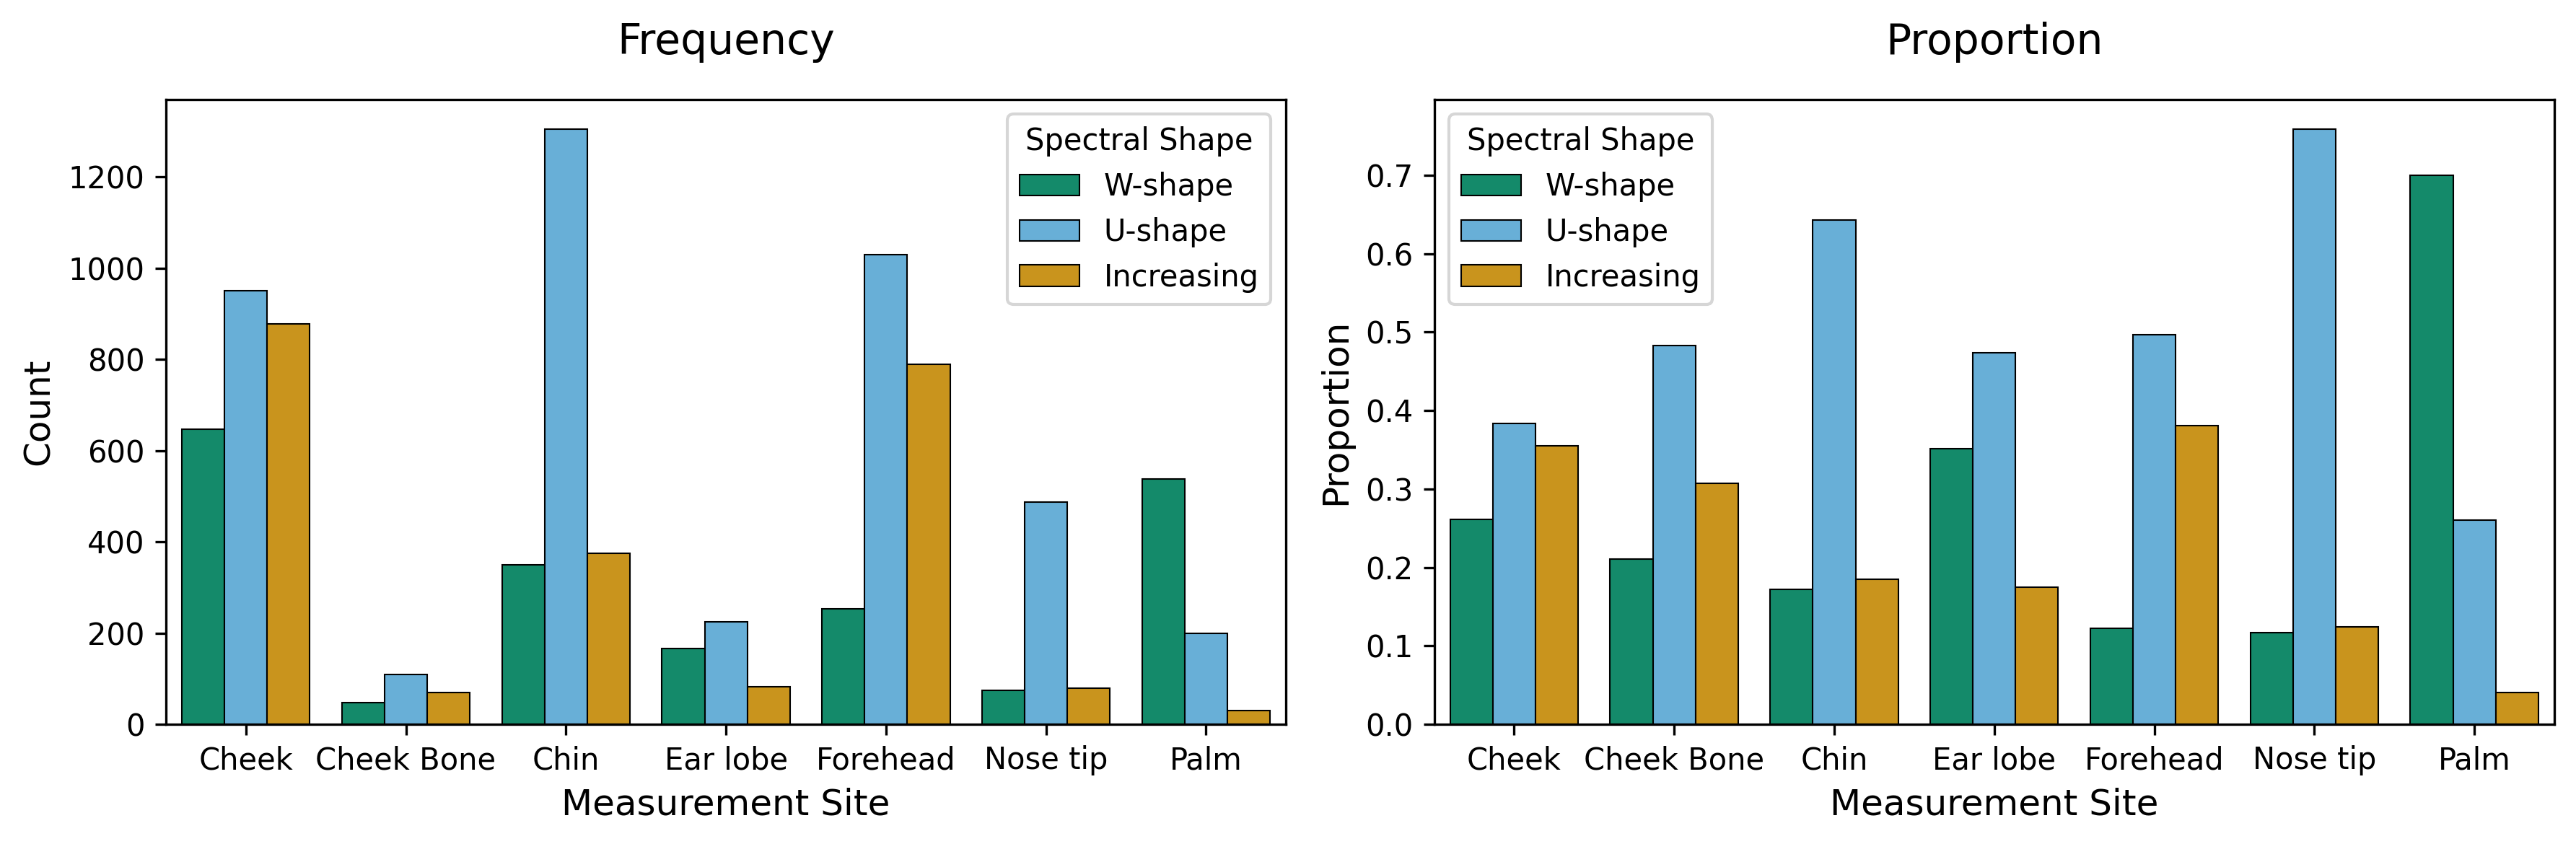

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12, 4), dpi=300)

# Define the logical order for your categories
site_order = face_palm_freq_table.index.tolist()
shape_order = ['W-shape', 'U-shape', 'Increasing']

# Frequency plot of shape classifications by site
# Use countplot for categorical x-axis variables
ax = axes[0]
sns.countplot(
    data=face_palm_df, 
    x='Site', 
    hue='Shape', 
    order=site_order,
    hue_order=shape_order,
    palette=['#009E73', '#56B4E9', '#E69F00'], # Okabe-Ito colorblind palette
    edgecolor='black',
    linewidth=0.5,
    ax=ax
)

ax.set_title('Frequency', fontsize=14, pad=15)
ax.set_xlabel('Measurement Site', fontsize=12)
ax.set_ylabel('Count', fontsize=12)

# Ensure the legend clearly explains the grouping
ax.legend(title="Spectral Shape")

# Proportion plot of shape classifications by site
# Use barplot for categorical x-axis variables
ax = axes[1]
face_palm_prop_melted = face_palm_prop_table.reset_index().melt(id_vars='Site', var_name='Shape', value_name='Proportion')
sns.barplot(
    data=face_palm_prop_melted,
    x='Site',
    y='Proportion',
    hue='Shape',
    order=site_order,
    hue_order=shape_order,
    palette=['#009E73', '#56B4E9', '#E69F00'], # Okabe-Ito colorblind palette
    edgecolor='black',
    linewidth=0.5,
    ax=ax
)

ax.set_title('Proportion', fontsize=14, pad=15)
ax.set_xlabel('Measurement Site', fontsize=12)
ax.set_ylabel('Proportion', fontsize=12)

# Ensure the legend clearly explains the grouping
ax.legend(title="Spectral Shape")

# plt.suptitle(f'Spectrum Shape Classifications by Body Site', fontsize=14)
plt.tight_layout()
plt.savefig('../figures/spectrum_shape_classifications_by_body_site.png', bbox_inches='tight')
plt.show()

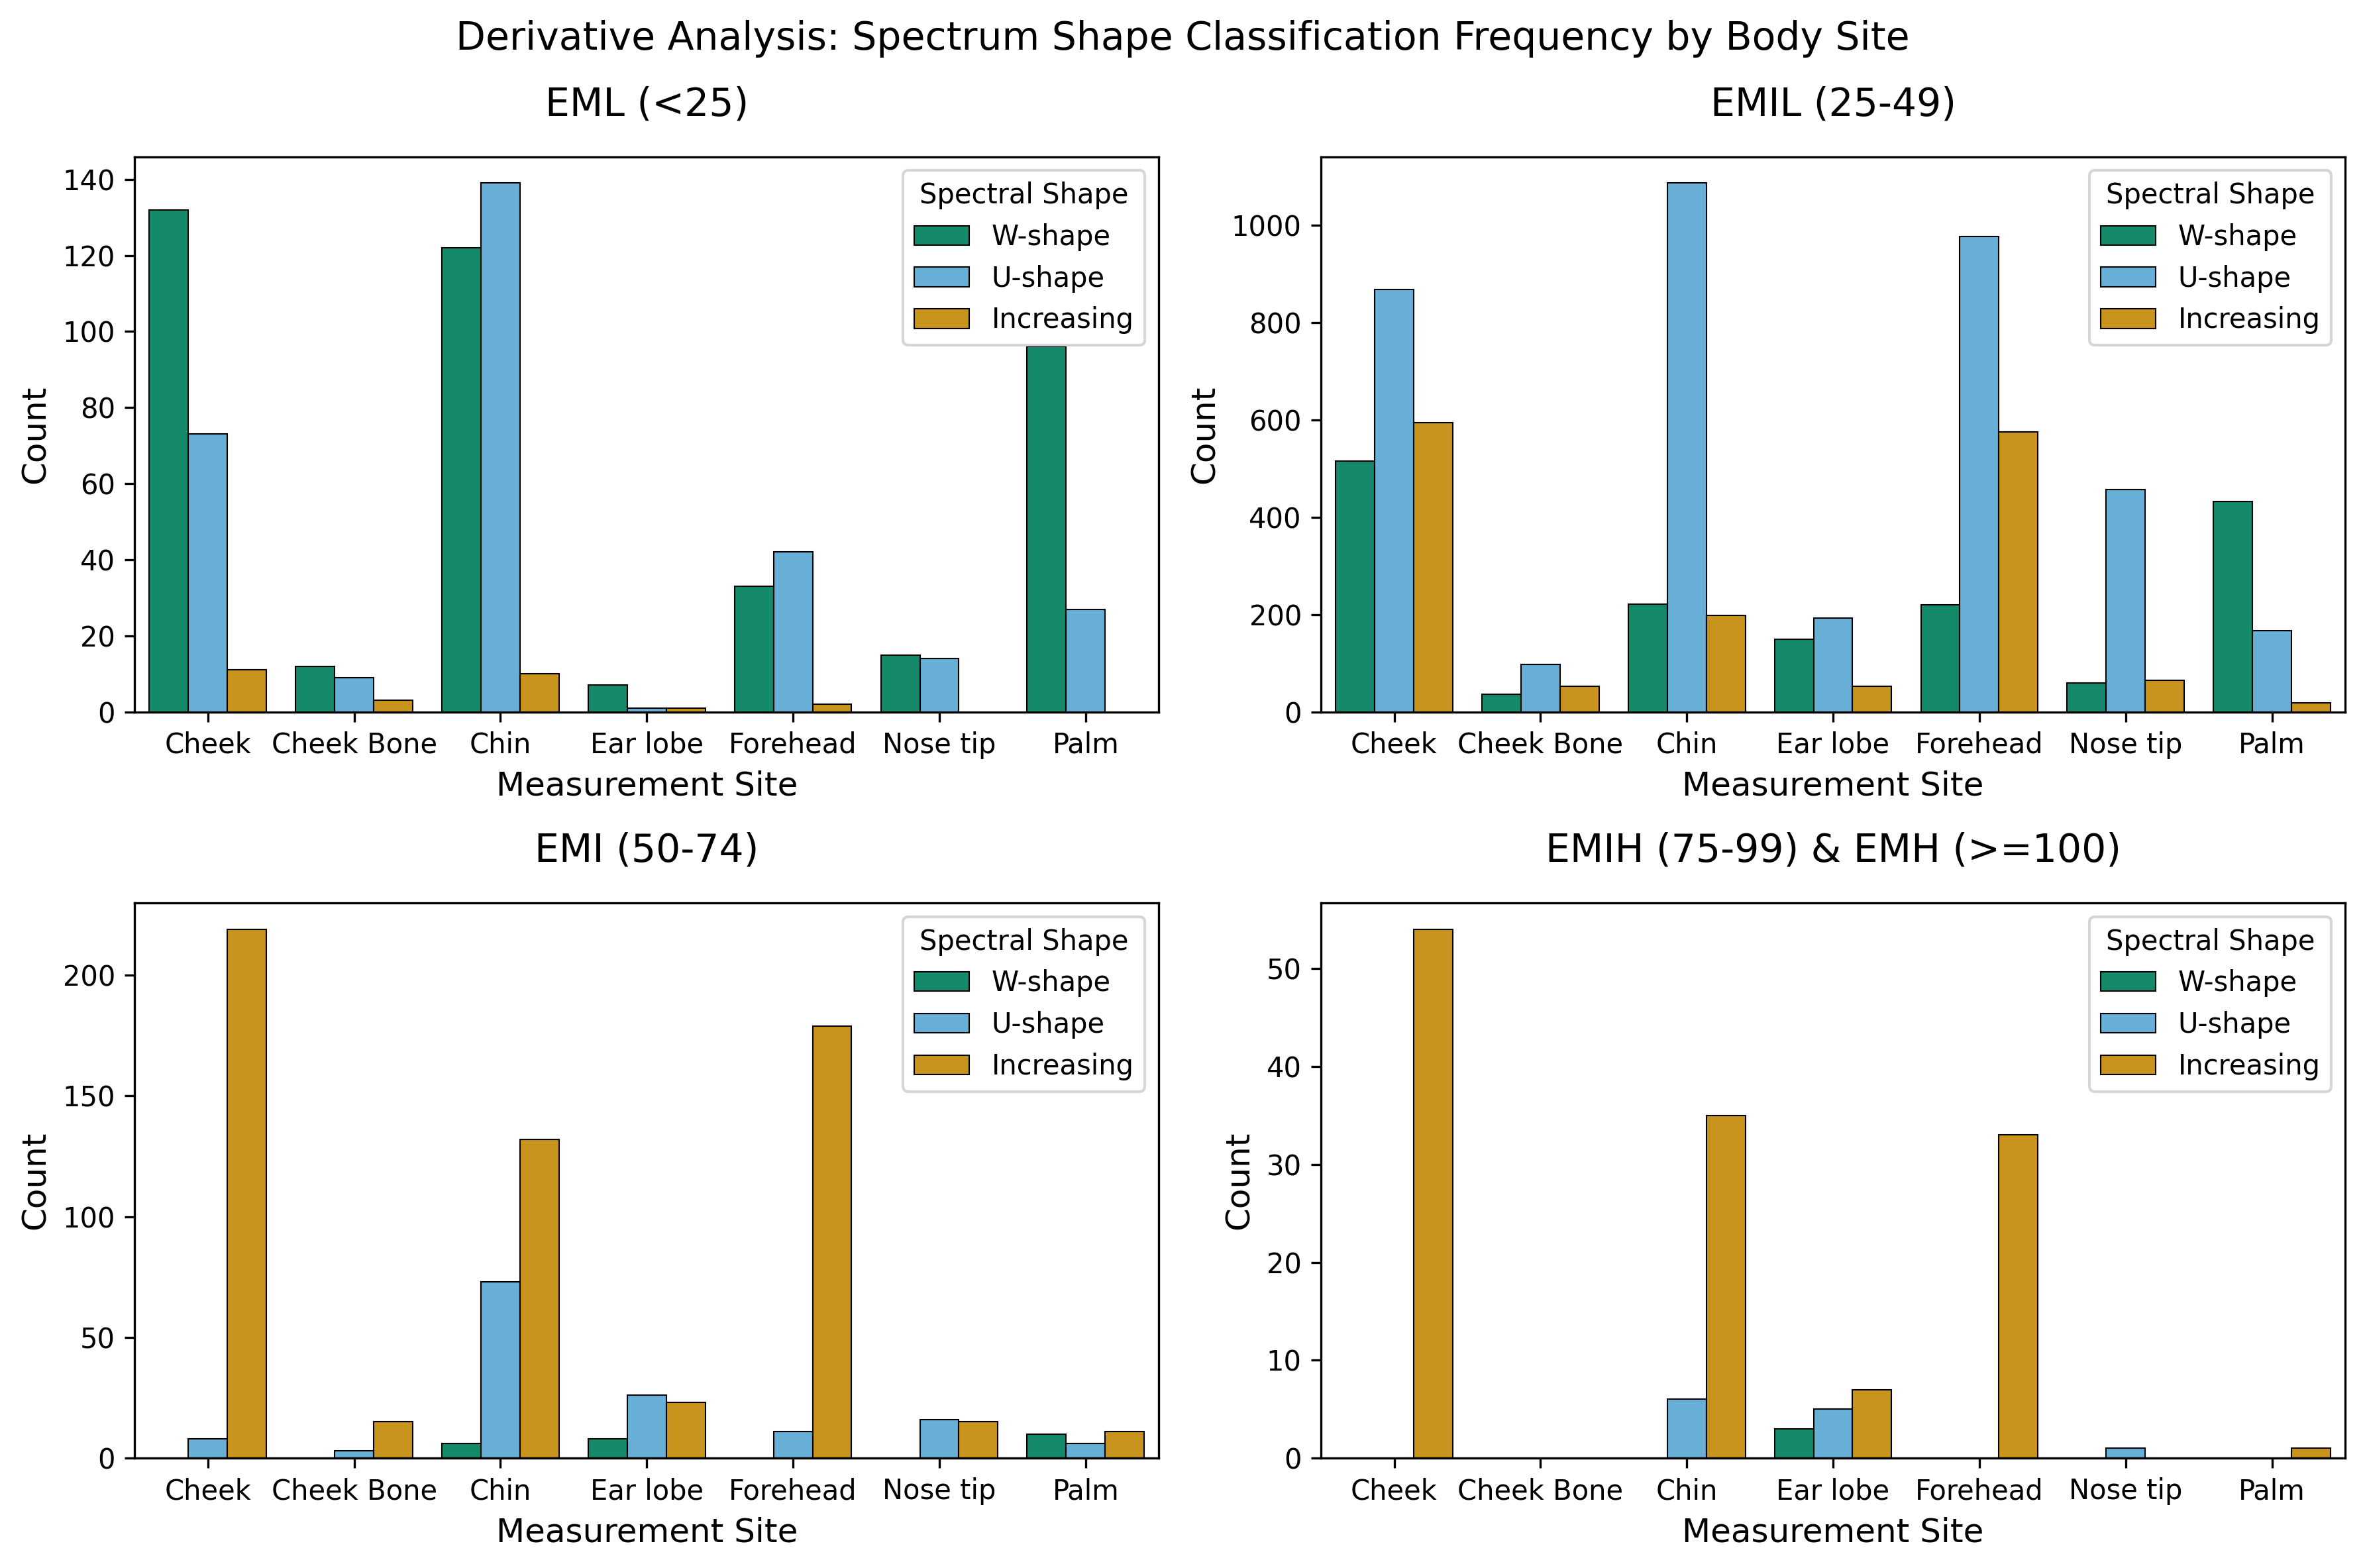

In [11]:
# Create side-by-side frequency plots of shape classifications by eumelanin class for face and palm sites
fig, axes = plt.subplots(2, 2, figsize=(12, 8), dpi=300)

# Define the logical order for your categories
site_order = face_palm_freq_table.index.tolist()
shape_order = ['W-shape', 'U-shape', 'Increasing']

# Merge EMIH (75-99) and EMH (>=100) classes for better visualization
face_palm_merged_df = face_palm_df.copy()
# face_palm_merged_df['Eumelanin Class'] = face_palm_df['Eumelanin Class'].replace(['EMIH (75-99)', 'EMH (>=100)'], 'EMIH (75-99) & EMH (>=100)')
em_classes = ['EML (<25)', 'EMIL (25-49)', 'EMI (50-74)', 'EMIH (75-99) & EMH (>=100)']

# Frequency plot of shape classifications by site
# Use countplot for categorical x-axis variables
for i, em_class in enumerate(em_classes):
    ax = axes[i // 2, i % 2]
    em_mask = face_palm_merged_df['Eumelanin Class'] == em_class
    sns.countplot(
        data=face_palm_merged_df[em_mask], 
        x='Site', 
        hue='Shape', 
        order=site_order,
        hue_order=shape_order,
        palette=['#009E73', '#56B4E9', '#E69F00'], # Okabe-Ito colorblind palette
        edgecolor='black',
        linewidth=0.5,
        ax=ax
    )

    ax.set_title(f'{em_class}', fontsize=14, pad=15)
    ax.set_xlabel('Measurement Site', fontsize=12)
    ax.set_ylabel('Count', fontsize=12)

    # Ensure the legend clearly explains the grouping
    ax.legend(title="Spectral Shape")

plt.suptitle(f'Derivative Analysis: Spectrum Shape Classification Frequency by Body Site', fontsize=14)
plt.tight_layout()
plt.show()

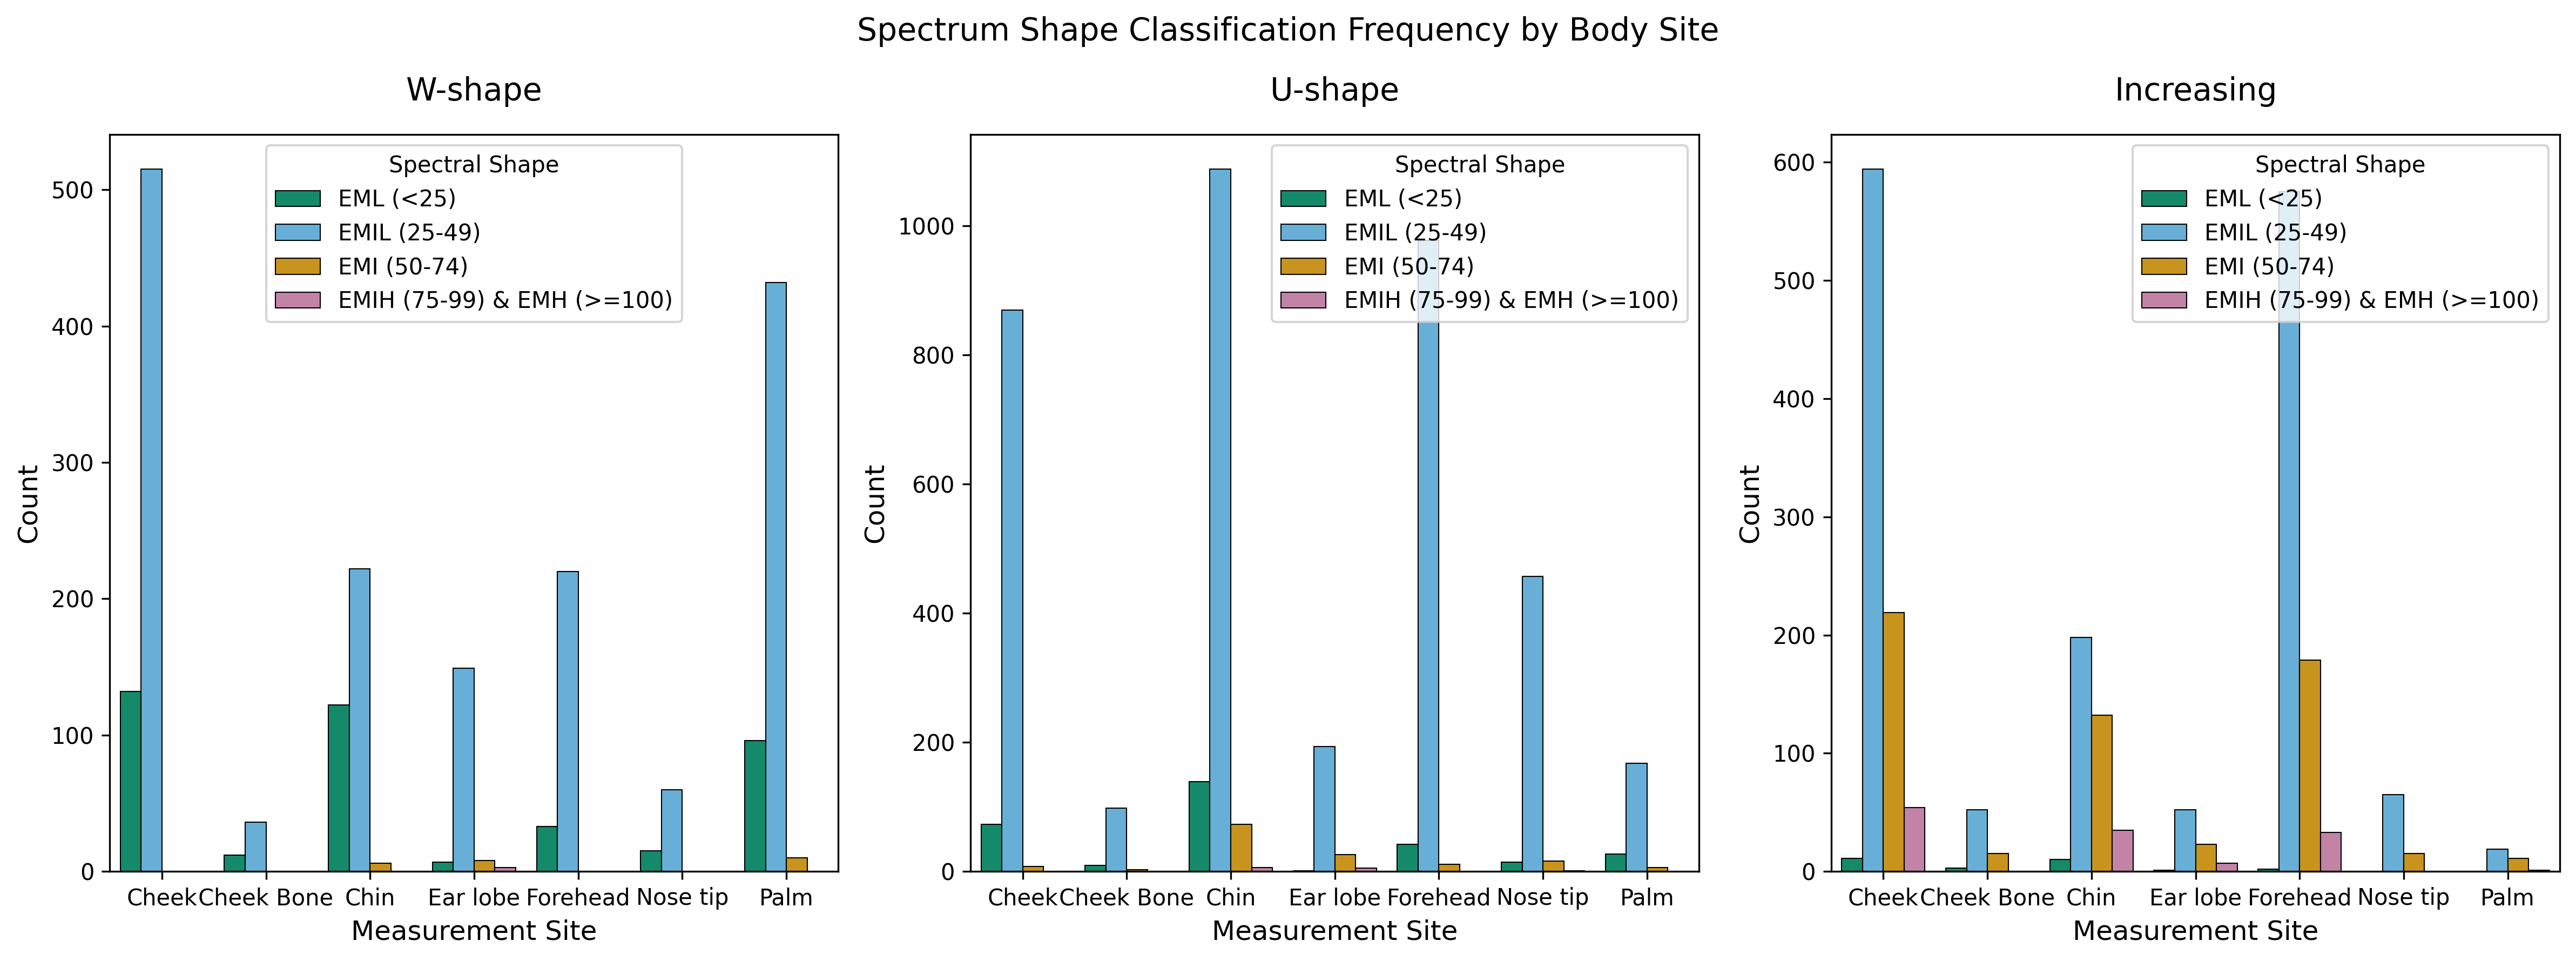

In [12]:
# Create side-by-side frequency plots of shape classifications by eumelanin class for face and palm sites
fig, axes = plt.subplots(1,3, figsize=(16, 6), dpi=300)

# Define the logical order for your categories
site_order = face_palm_freq_table.index.tolist()
shape_order = ['W-shape', 'U-shape', 'Increasing']

# Merge EMIH (75-99) and EMH (>=100) classes for better visualization
face_palm_merged_df = face_palm_df.copy()
# face_palm_merged_df['Eumelanin Class'] = face_palm_df['Eumelanin Class'].replace(['EMIH (75-99)', 'EMH (>=100)'], 'EMIH (75-99) & EMH (>=100)')
em_classes = ['EML (<25)', 'EMIL (25-49)', 'EMI (50-74)', 'EMIH (75-99) & EMH (>=100)']

# Frequency plot of shape classifications by site
# Use countplot for categorical x-axis variables
for i, shape in enumerate(shape_order):
    ax = axes[i]
    shape_mask = face_palm_merged_df['Shape'] == shape
    sns.countplot(
        data=face_palm_merged_df[shape_mask], 
        x='Site', 
        hue='Eumelanin Class', 
        order=site_order,
        hue_order=em_classes,
        palette=['#009E73', '#56B4E9', '#E69F00', '#CC79A7'], # Okabe-Ito colorblind palette
        edgecolor='black',
        linewidth=0.5,
        ax=ax
    )

    ax.set_title(f'{shape}', fontsize=14, pad=15)
    ax.set_xlabel('Measurement Site', fontsize=12)
    ax.set_ylabel('Count', fontsize=12)

    # Ensure the legend clearly explains the grouping
    ax.legend(title="Spectral Shape")

plt.suptitle(f'Spectrum Shape Classification Frequency by Body Site', fontsize=14)
plt.tight_layout()
plt.show()

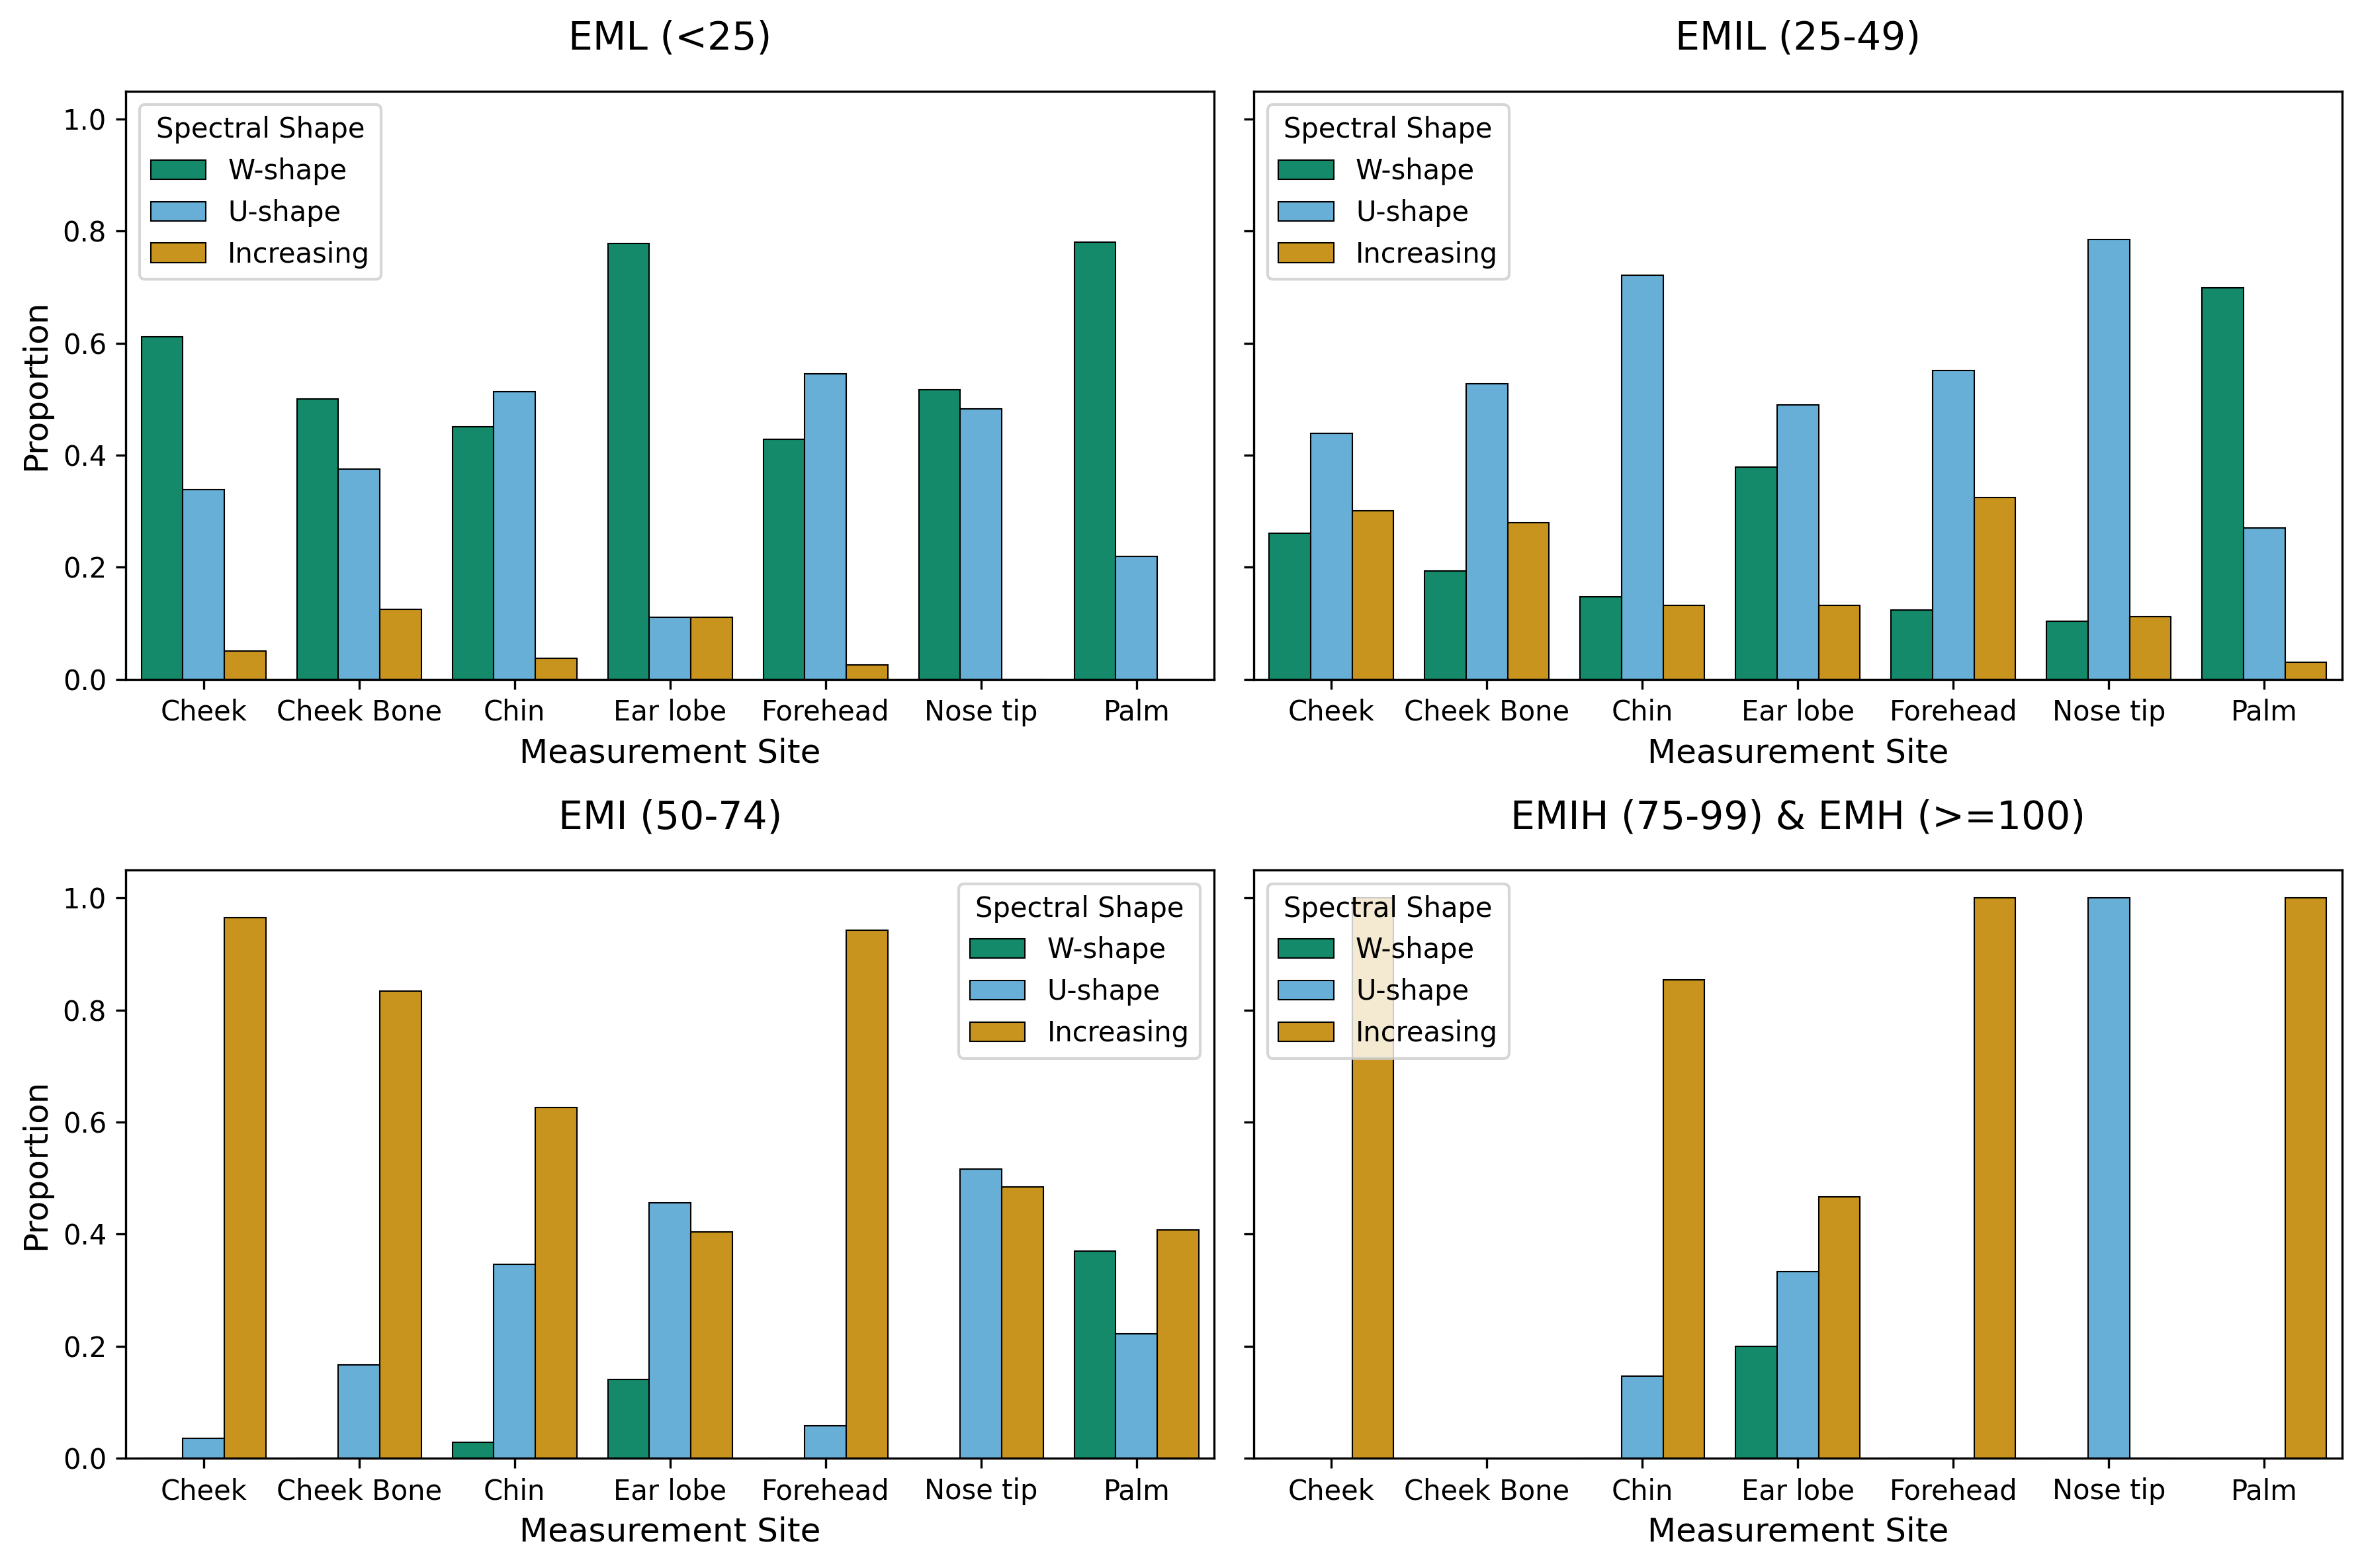

In [14]:
# Create side-by-side proportion plots of shape classifications by eumelanin class for face and palm sites

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharey=True, dpi=300)

# Define the logical order for your categories
site_order = face_palm_freq_table.index.tolist()
shape_order = ['W-shape', 'U-shape', 'Increasing']

# Merge EMIH (75-99) and EMH (>=100) classes for better visualization
face_palm_merged_df = face_palm_df.copy()
# face_palm_merged_df['Eumelanin Class'] = face_palm_df['Eumelanin Class'].replace(['EMIH (75-99)', 'EMH (>=100)'], 'EMIH (75-99) & EMH (>=100)')
em_classes = ['EML (<25)', 'EMIL (25-49)', 'EMI (50-74)', 'EMIH (75-99) & EMH (>=100)']

# Frequency plot of shape classifications by site
# Use countplot for categorical x-axis variables
for i, em_class in enumerate(em_classes):
    ax = axes[i // 2, i % 2]
    em_mask = face_palm_merged_df['Eumelanin Class'] == em_class
    face_palm_em_df = face_palm_merged_df[em_mask]
    face_palm_freq_em = pd.crosstab(face_palm_em_df['Site'], face_palm_em_df['Shape'])
    face_palm_prop_em = face_palm_freq_em.div(face_palm_freq_em.sum(axis=1), axis=0)
    
    face_palm_prop_melted = face_palm_prop_em.reset_index().melt(id_vars='Site', var_name='Shape', value_name='Proportion')
    sns.barplot(
        data=face_palm_prop_melted,
        x='Site',
        y='Proportion',
        hue='Shape',
        order=site_order,
        hue_order=shape_order,
        palette=['#009E73', '#56B4E9', '#E69F00'], # Okabe-Ito colorblind palette
        edgecolor='black',
        linewidth=0.5,
        ax=ax
    )

    ax.set_title(f'{em_class}', fontsize=14, pad=15)
    ax.set_xlabel('Measurement Site', fontsize=12)
    ax.set_ylabel('Proportion', fontsize=12)

    # Ensure the legend clearly explains the grouping
    ax.legend(title="Spectral Shape")

#plt.suptitle(f'Spectrum Shape Classification Proportions by Body Site', fontsize=14)
plt.tight_layout()
plt.savefig('../figures/spectrum_shape_classification_proportions_by_eumelanin_class.png', bbox_inches='tight')
plt.show()

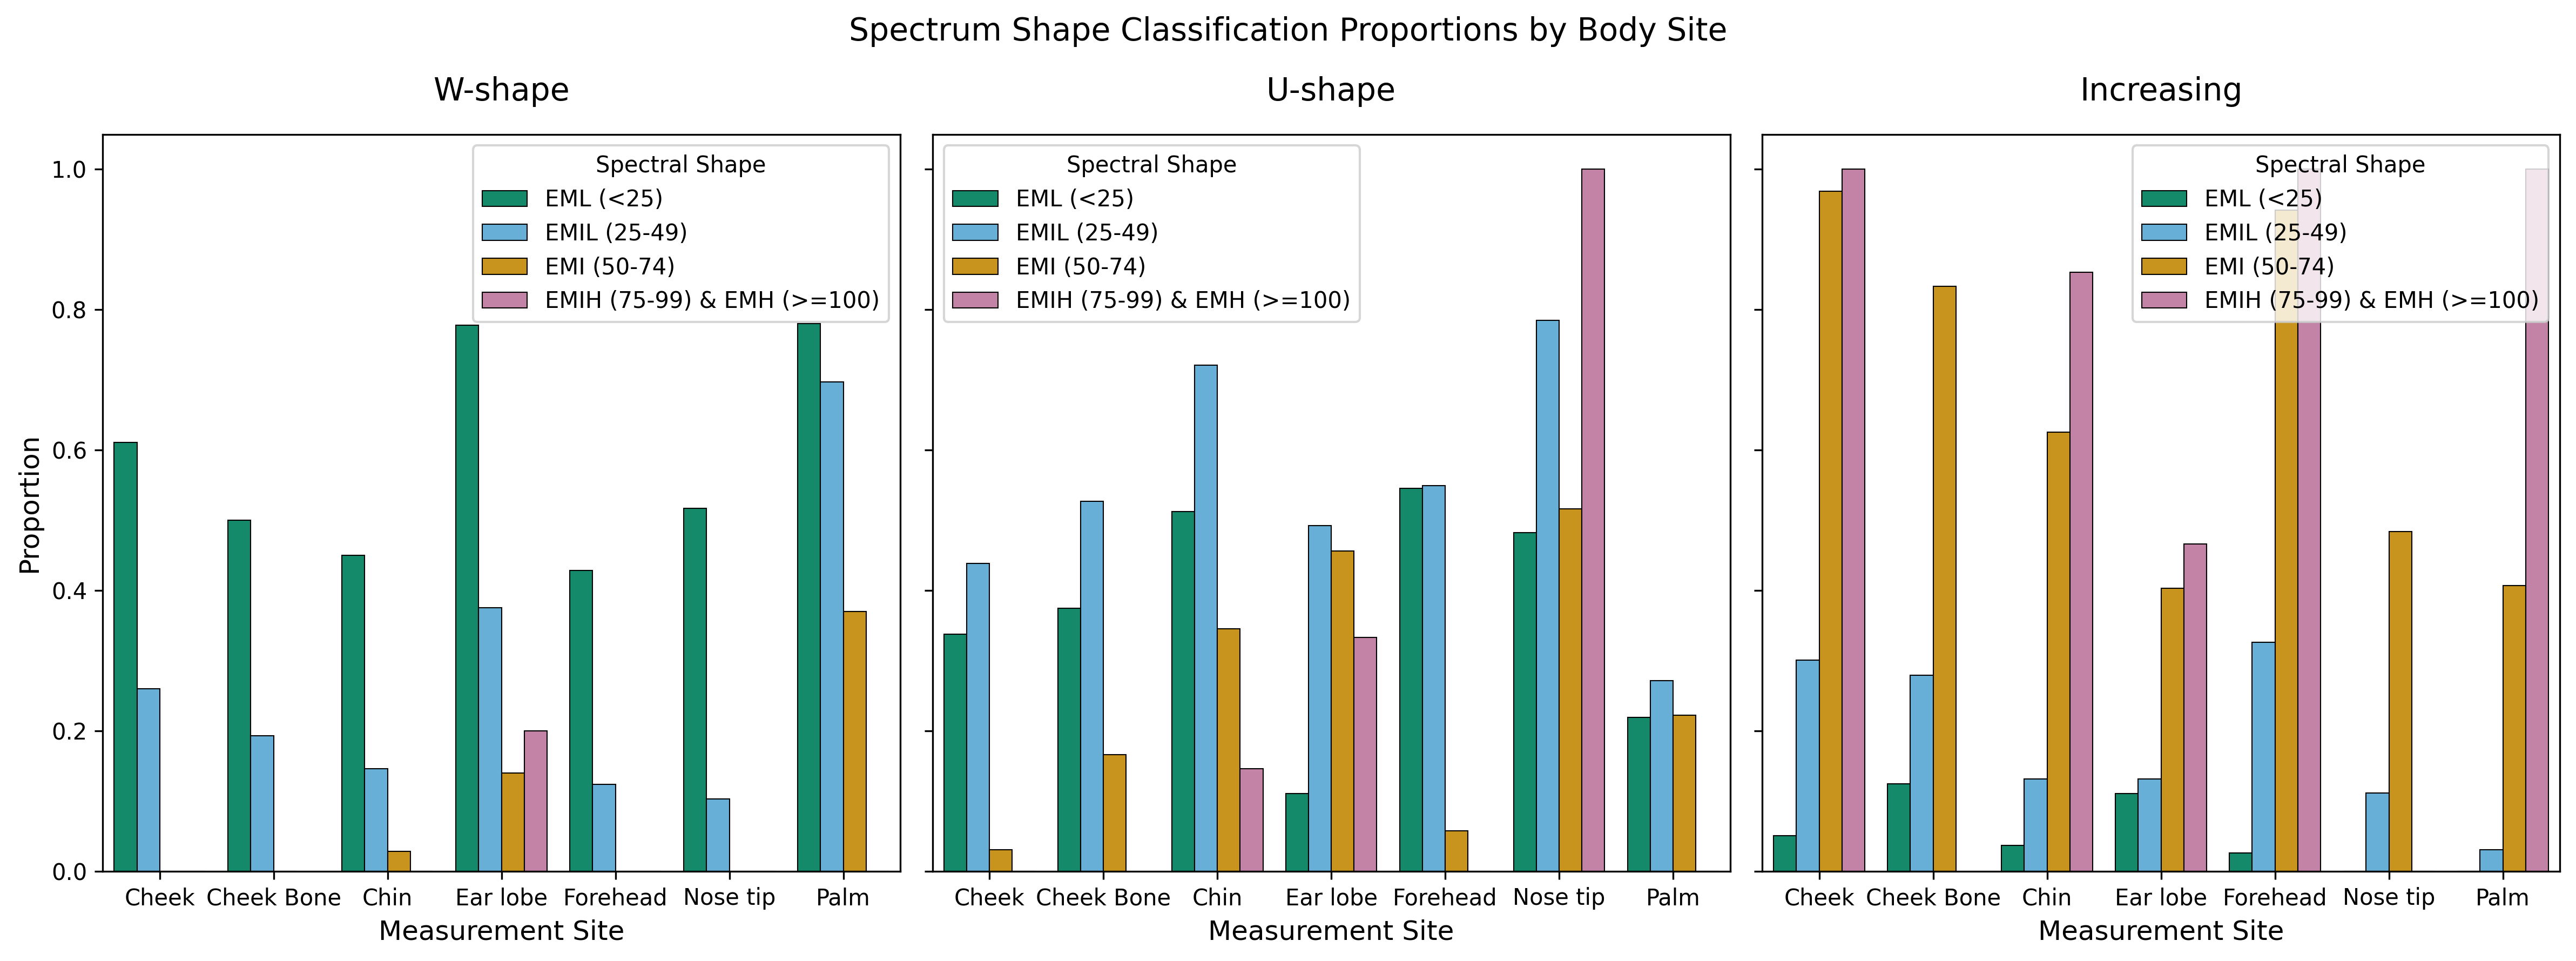

In [44]:
# Create side-by-side proportion plots of shape classifications by eumelanin class for face and palm sites
fig, axes = plt.subplots(1, 3, figsize=(16, 6), sharey=True, dpi=300)

# Define the logical order for your categories
site_order = face_palm_freq_table.index.tolist()
shape_order = ['W-shape', 'U-shape', 'Increasing']

# Merge EMIH (75-99) and EMH (>=100) classes for better visualization
face_palm_merged_df = face_palm_df.copy()
# face_palm_merged_df['Eumelanin Class'] = face_palm_df['Eumelanin Class'].replace(['EMIH (75-99)', 'EMH (>=100)'], 'EMIH (75-99) & EMH (>=100)')
em_classes = ['EML (<25)', 'EMIL (25-49)', 'EMI (50-74)', 'EMIH (75-99) & EMH (>=100)']

# Frequency plot of shape classifications by site
# Use countplot for categorical x-axis variables
for i, shape in enumerate(shape_order):
    ax = axes[i]
    face_palm_prop_shape = face_palm_shape_eumelanin_prop_table[[shape]].reset_index()
    face_palm_prop_shape.columns = ['Site', 'Eumelanin Class', 'Proportion']
    sns.barplot(
        data=face_palm_prop_shape,
        x='Site',
        y='Proportion',
        hue='Eumelanin Class',
        order=site_order,
        hue_order=em_classes,
        palette=['#009E73', '#56B4E9', '#E69F00', '#CC79A7'], # Okabe-Ito colorblind palette
        edgecolor='black',
        linewidth=0.5,
        ax=ax
    )

    ax.set_title(f'{shape}', fontsize=14, pad=15)
    ax.set_xlabel('Measurement Site', fontsize=12)
    ax.set_ylabel('Proportion', fontsize=12)

    # Ensure the legend clearly explains the grouping
    ax.legend(title="Spectral Shape")

plt.suptitle(f'Spectrum Shape Classification Proportions by Body Site', fontsize=14)
plt.tight_layout()
plt.show()

## Skin reflectance spectra on forehead and palm

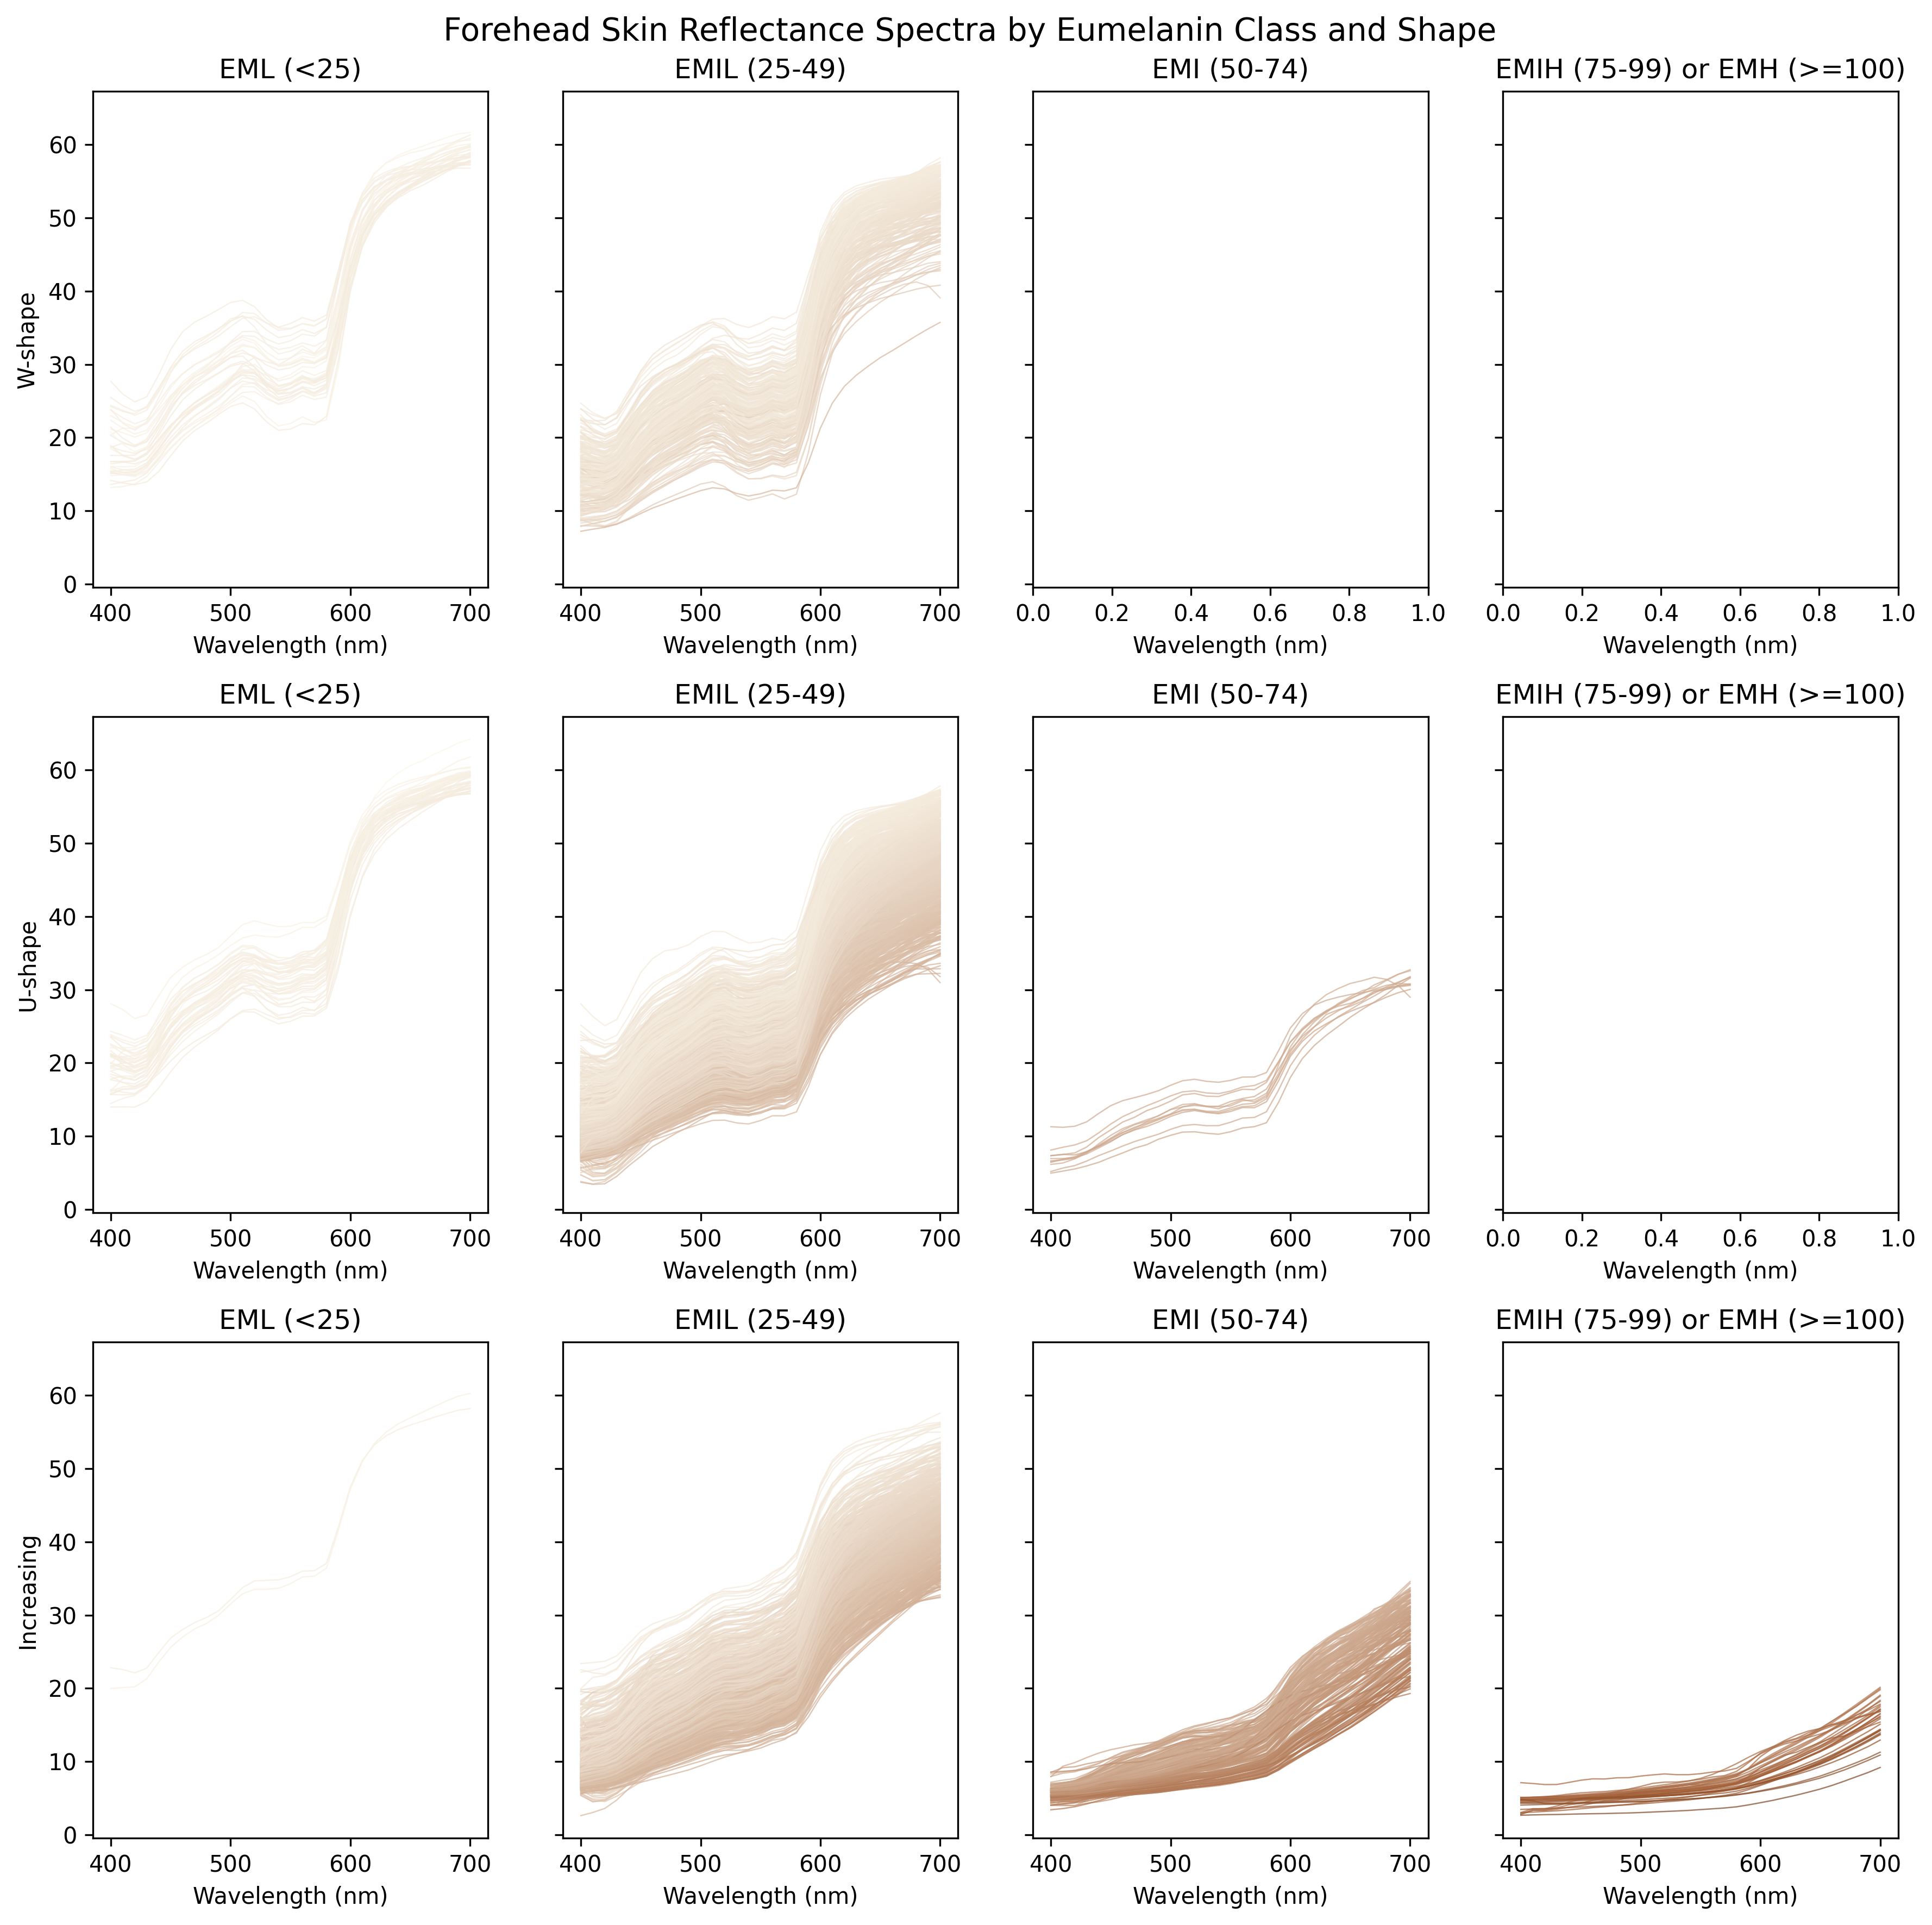

In [46]:
# Visualize the skin reflectance spectra by eumelanin class for each shape category
fitzpatrick = ["#fbf7ec", "#a15c33", "#42230c"]
cmap = LinearSegmentedColormap.from_list("fitzpatrick", fitzpatrick)
norm = plt.Normalize(vmin=20, vmax=150)

fig, axes = plt.subplots(3, 4, figsize=(12, 12), dpi=300, sharey=True)

for i, shape in enumerate(shape_order):
    # Plot ISSA spectra
    ax = axes[i, 0]
    eml_mask = (forehead_df['Eumelanin Class'] == 'EML (<25)') & (forehead_df['Shape'] == shape)
    eml_indices = forehead_df[eml_mask].index
    for j in eml_indices:
        color = cmap(norm(forehead_mi[j]))
        ax.plot(issa_wavelengths, forehead_spectra_clean[j, :], color=color, alpha=0.7, linewidth=0.6)
    ax.set_title('EML (<25)')
    ax.set_ylabel(shape)
    ax.set_xlabel('Wavelength (nm)')

    # Plot ISSA spectra
    ax = axes[i, 1]
    emil_mask = (forehead_df['Eumelanin Class'] == 'EMIL (25-49)') & (forehead_df['Shape'] == shape)
    emil_indices = forehead_df[emil_mask].index
    for j in emil_indices:
        color = cmap(norm(forehead_mi[j]))
        ax.plot(issa_wavelengths, forehead_spectra_clean[j, :], color=color, alpha=0.7, linewidth=0.6)
    ax.set_title('EMIL (25-49)')
    ax.set_xlabel('Wavelength (nm)')

    # Plot ISSA spectra
    ax = axes[i, 2]
    emi_mask = (forehead_df['Eumelanin Class'] == 'EMI (50-74)') & (forehead_df['Shape'] == shape)
    emi_indices = forehead_df[emi_mask].index
    for j in emi_indices:
        color = cmap(norm(forehead_mi[j]))
        ax.plot(issa_wavelengths, forehead_spectra_clean[j, :], color=color, alpha=0.7, linewidth=0.6)
    ax.set_title('EMI (50-74)')
    ax.set_xlabel('Wavelength (nm)')

    # Plot ISSA spectra
    ax = axes[i, 3]
    emh_mask = ((forehead_df['Eumelanin Class'] == 'EMIH (75-99)') | (forehead_df['Eumelanin Class'] == 'EMH (>=100)')) & (forehead_df['Shape'] == shape)
    emh_indices = forehead_df[emh_mask].index
    for j in emh_indices:
        color = cmap(norm(forehead_mi[j]))
        ax.plot(issa_wavelengths, forehead_spectra_clean[j, :], color=color, alpha=0.7, linewidth=0.6)
    ax.set_title('EMIH (75-99) or EMH (>=100)')
    ax.set_xlabel('Wavelength (nm)')

plt.suptitle(f'Forehead Skin Reflectance Spectra by Eumelanin Class and Shape', fontsize=14)
plt.tight_layout()
plt.show()

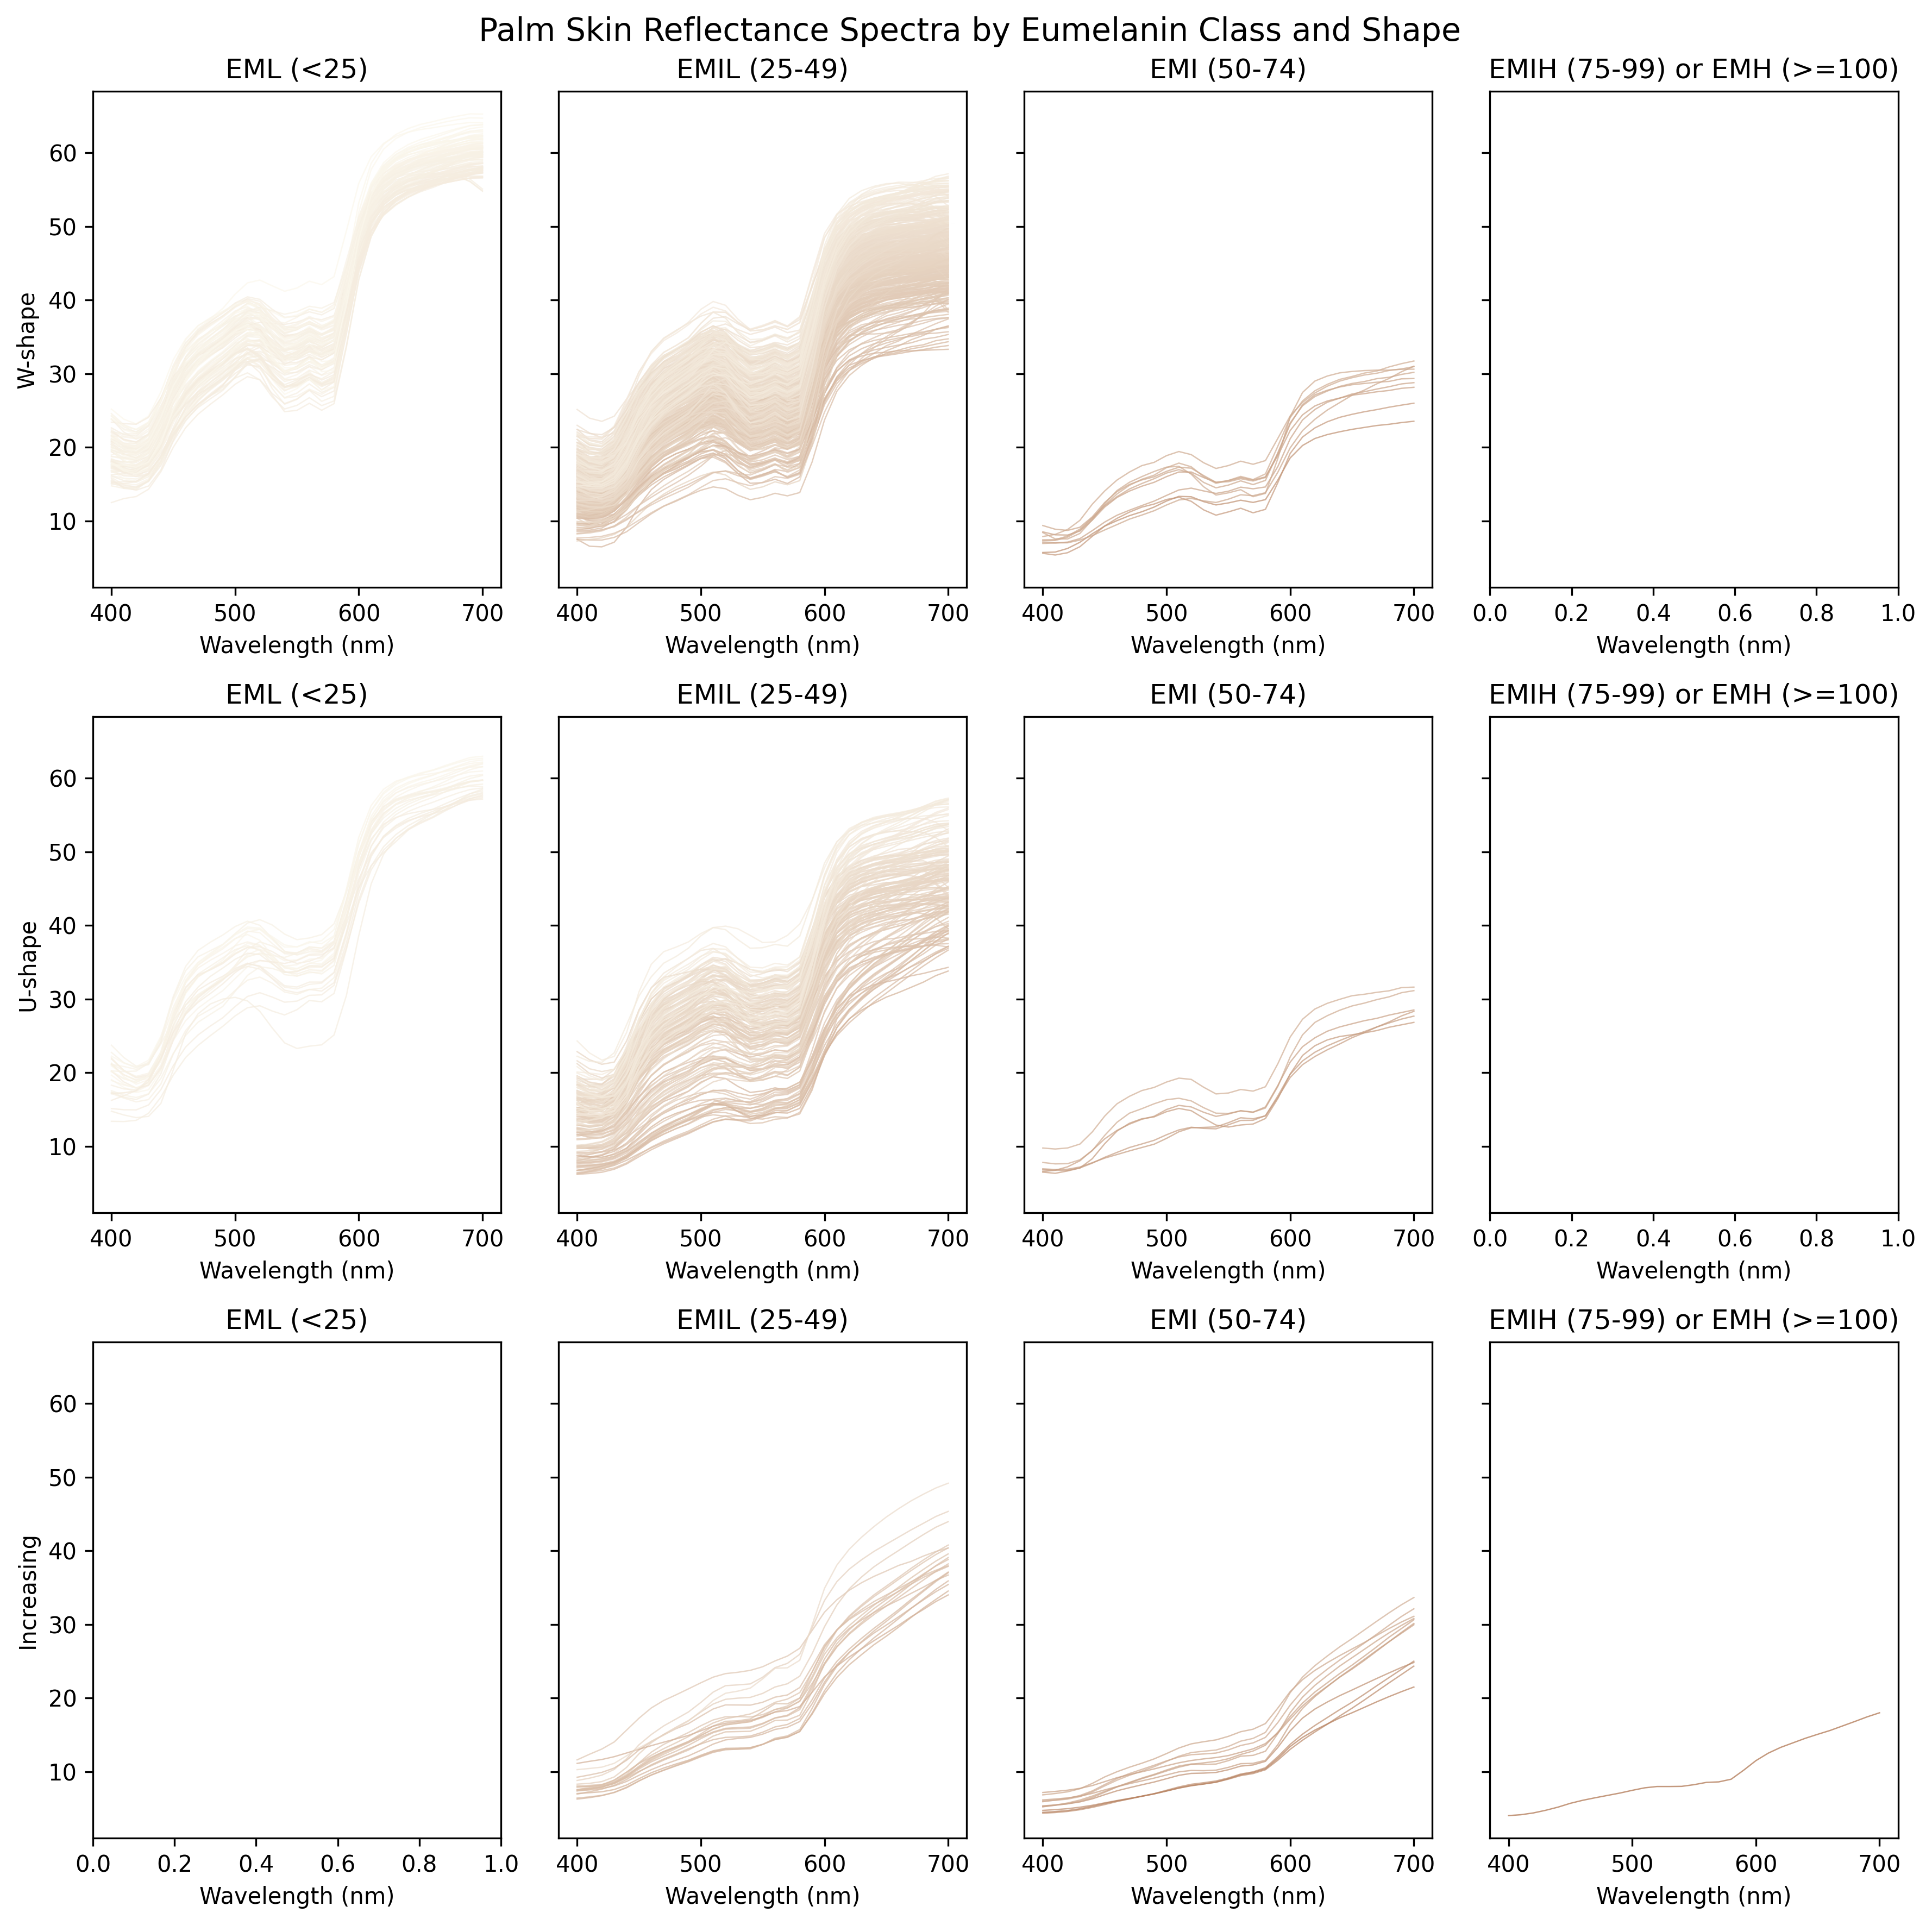

In [47]:
# Visualize the skin reflectance spectra by eumelanin class for each shape category
fitzpatrick = ["#fbf7ec", "#a15c33", "#42230c"]
cmap = LinearSegmentedColormap.from_list("fitzpatrick", fitzpatrick)
norm = plt.Normalize(vmin=20, vmax=150)

fig, axes = plt.subplots(3, 4, figsize=(12, 12), dpi=300, sharey=True)

for i, shape in enumerate(shape_order):
    # Plot ISSA spectra
    ax = axes[i, 0]
    eml_mask = (palm_df['Eumelanin Class'] == 'EML (<25)') & (palm_df['Shape'] == shape)
    eml_indices = palm_df[eml_mask].index
    for j in eml_indices:
        color = cmap(norm(palm_mi[j]))
        ax.plot(issa_wavelengths, palm_spectra_clean[j, :], color=color, alpha=0.7, linewidth=0.6)
    ax.set_title('EML (<25)')
    ax.set_ylabel(shape)
    ax.set_xlabel('Wavelength (nm)')

    # Plot ISSA spectra
    ax = axes[i, 1]
    emil_mask = (palm_df['Eumelanin Class'] == 'EMIL (25-49)') & (palm_df['Shape'] == shape)
    emil_indices = palm_df[emil_mask].index
    for j in emil_indices:
        color = cmap(norm(palm_mi[j]))
        ax.plot(issa_wavelengths, palm_spectra_clean[j, :], color=color, alpha=0.7, linewidth=0.6)
    ax.set_title('EMIL (25-49)')
    ax.set_xlabel('Wavelength (nm)')

    # Plot ISSA spectra
    ax = axes[i, 2]
    emi_mask = (palm_df['Eumelanin Class'] == 'EMI (50-74)') & (palm_df['Shape'] == shape)
    emi_indices = palm_df[emi_mask].index
    for j in emi_indices:
        color = cmap(norm(palm_mi[j]))
        ax.plot(issa_wavelengths, palm_spectra_clean[j, :], color=color, alpha=0.7, linewidth=0.6)
    ax.set_title('EMI (50-74)')
    ax.set_xlabel('Wavelength (nm)')

    # Plot ISSA spectra
    ax = axes[i, 3]
    emh_mask = ((palm_df['Eumelanin Class'] == 'EMIH (75-99)') | (palm_df['Eumelanin Class'] == 'EMH (>=100)')) & (palm_df['Shape'] == shape)
    emh_indices = palm_df[emh_mask].index
    for j in emh_indices:
        color = cmap(norm(palm_mi[j]))
        ax.plot(issa_wavelengths, palm_spectra_clean[j, :], color=color, alpha=0.7, linewidth=0.6)
    ax.set_title('EMIH (75-99) or EMH (>=100)')
    ax.set_xlabel('Wavelength (nm)')

plt.suptitle(f'Palm Skin Reflectance Spectra by Eumelanin Class and Shape', fontsize=14)
plt.tight_layout()
plt.show()

## First derivative on forehead and palm

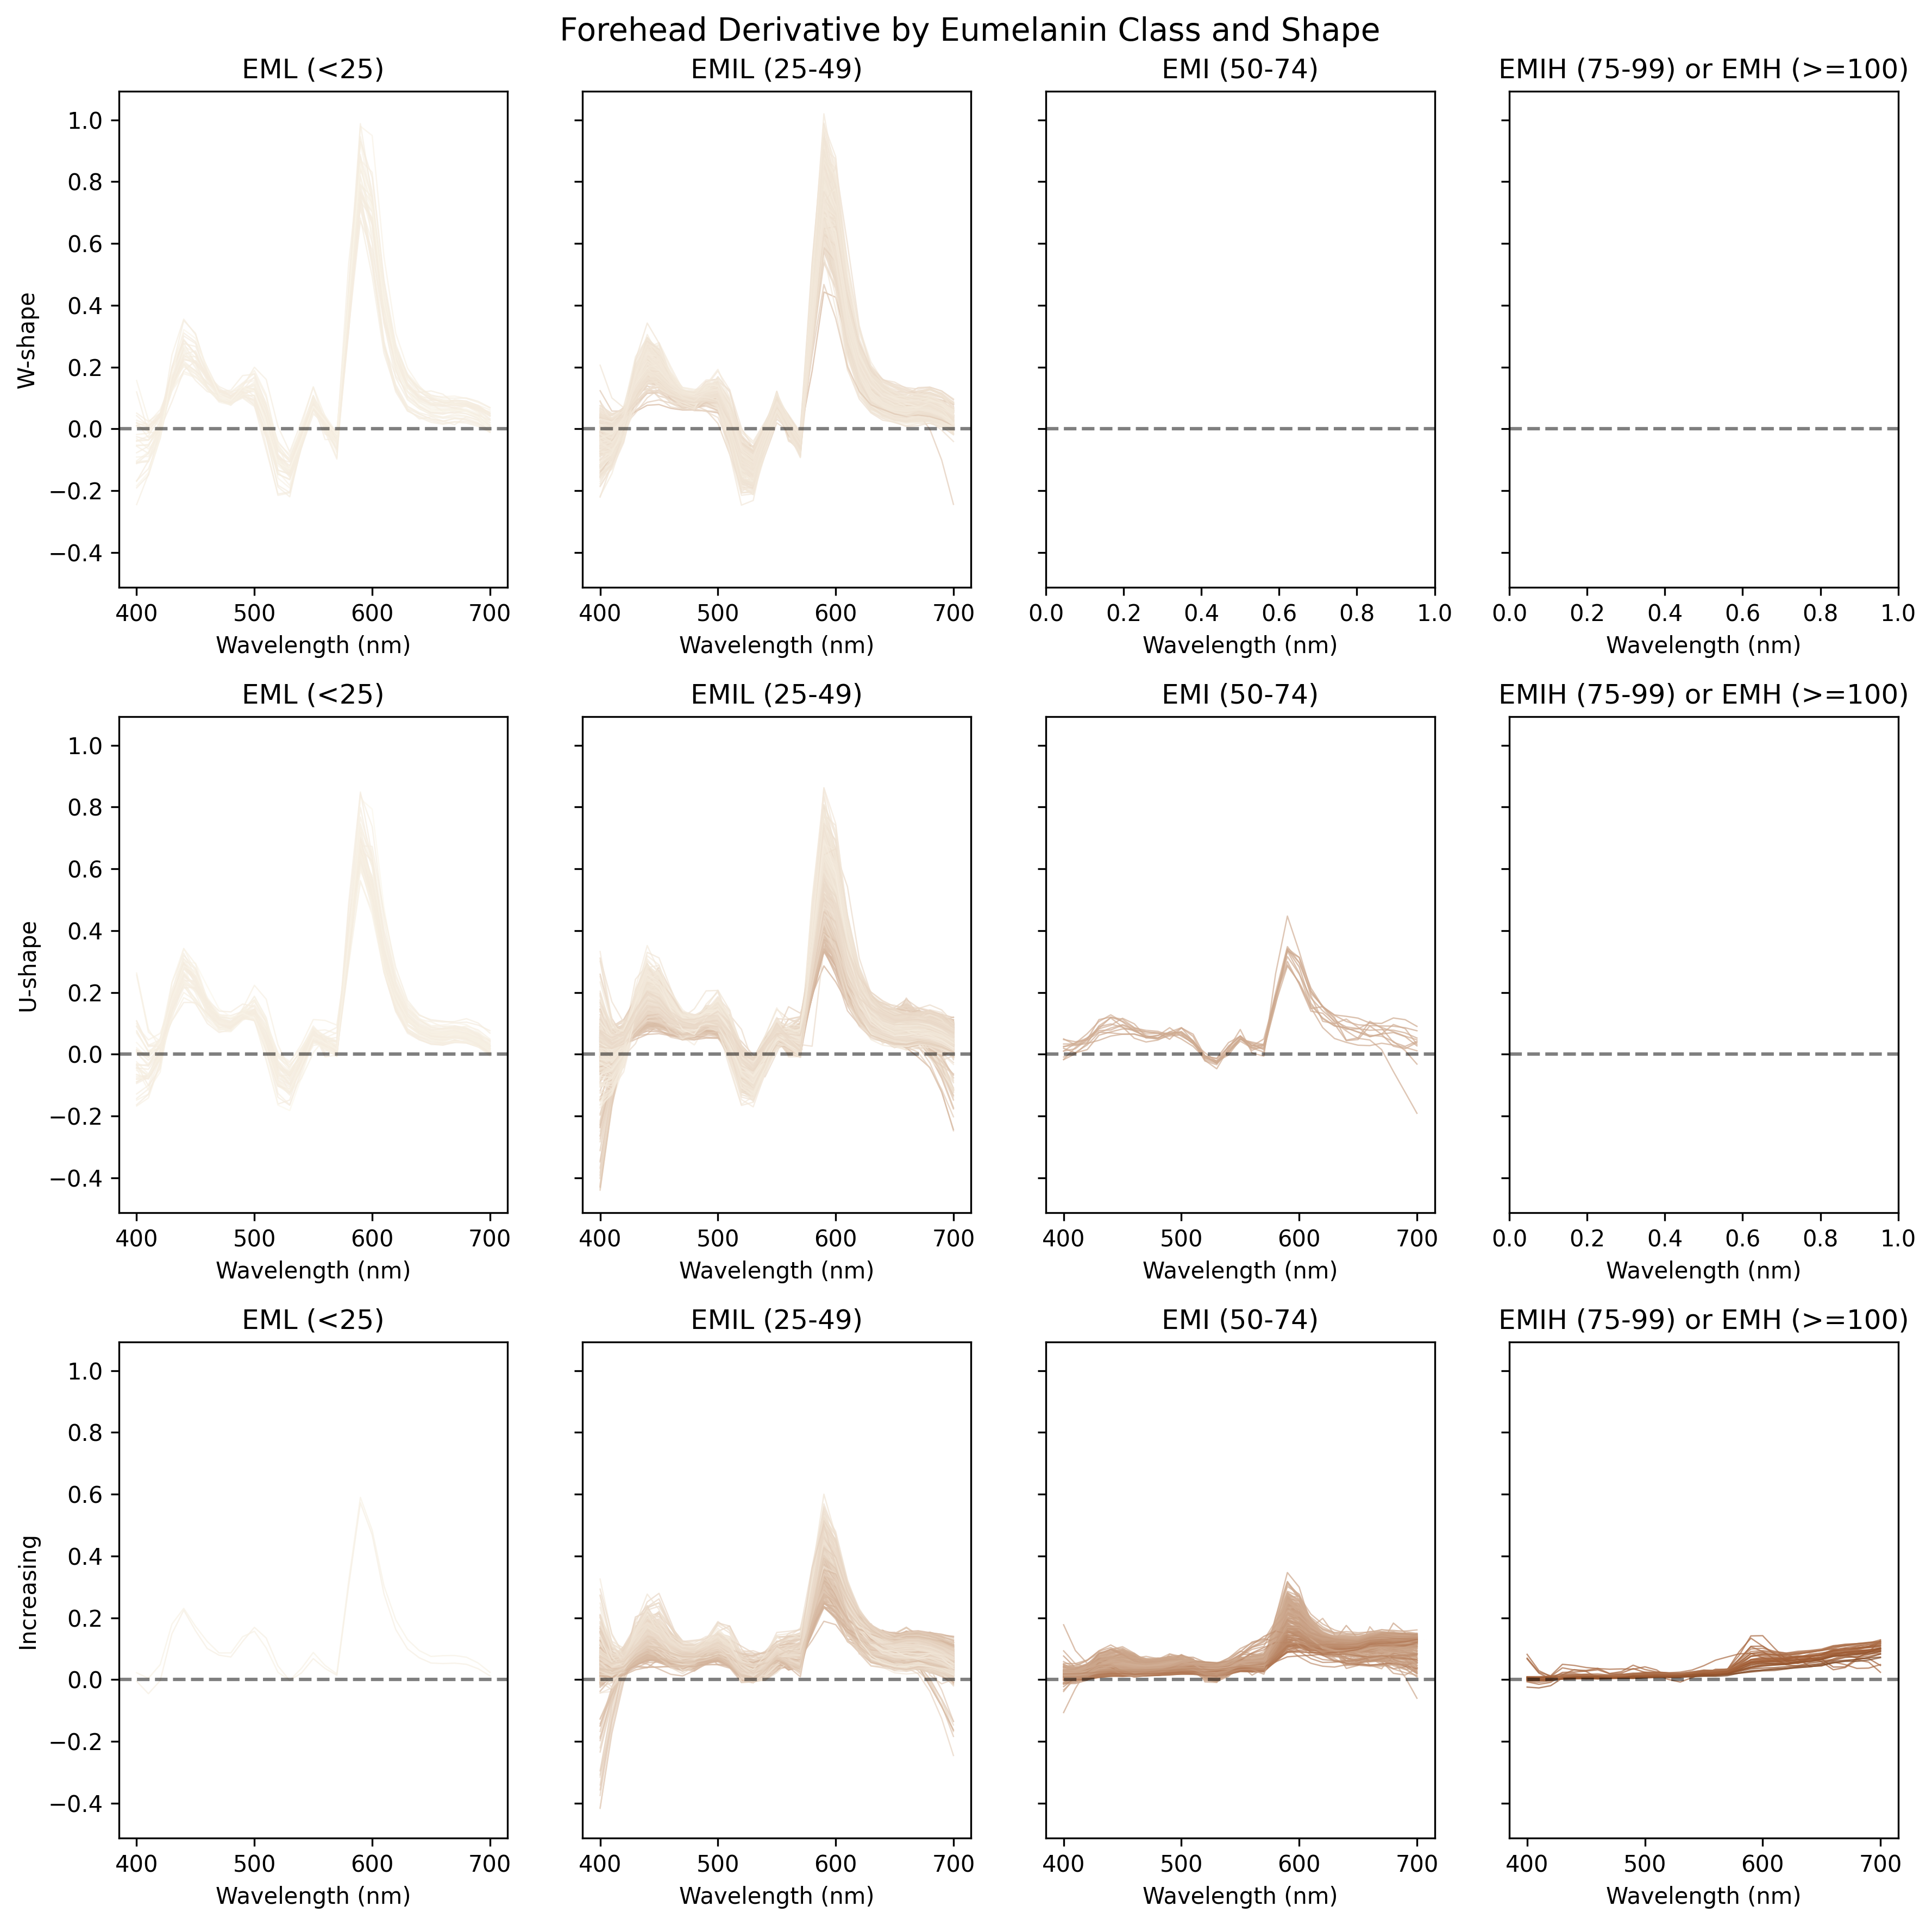

In [48]:
# Visualize the skin reflectance spectra by eumelanin class for each shape category
fitzpatrick = ["#fbf7ec", "#a15c33", "#42230c"]
cmap = LinearSegmentedColormap.from_list("fitzpatrick", fitzpatrick)
norm = plt.Normalize(vmin=20, vmax=150)

fig, axes = plt.subplots(3, 4, figsize=(12, 12), dpi=300, sharey=True)

for i, shape in enumerate(shape_order):
    # Plot ISSA spectra
    ax = axes[i, 0]
    eml_mask = (forehead_df['Eumelanin Class'] == 'EML (<25)') & (forehead_df['Shape'] == shape)
    eml_indices = forehead_df[eml_mask].index
    for j in eml_indices:
        color = cmap(norm(forehead_mi[j]))
        ax.plot(issa_wavelengths, forehead_drv_clean[j, :], color=color, alpha=0.7, linewidth=0.6)
    ax.set_title('EML (<25)')
    ax.set_ylabel(shape)
    ax.set_xlabel('Wavelength (nm)')
    ax.axhline(0, color='k', linestyle='--', alpha=0.5)

    # Plot ISSA spectra
    ax = axes[i, 1]
    emil_mask = (forehead_df['Eumelanin Class'] == 'EMIL (25-49)') & (forehead_df['Shape'] == shape)
    emil_indices = forehead_df[emil_mask].index
    for j in emil_indices:
        color = cmap(norm(forehead_mi[j]))
        ax.plot(issa_wavelengths, forehead_drv_clean[j, :], color=color, alpha=0.7, linewidth=0.6)
    ax.set_title('EMIL (25-49)')
    ax.set_xlabel('Wavelength (nm)')
    ax.axhline(0, color='k', linestyle='--', alpha=0.5)

    # Plot ISSA spectra
    ax = axes[i, 2]
    emi_mask = (forehead_df['Eumelanin Class'] == 'EMI (50-74)') & (forehead_df['Shape'] == shape)
    emi_indices = forehead_df[emi_mask].index
    for j in emi_indices:
        color = cmap(norm(forehead_mi[j]))
        ax.plot(issa_wavelengths, forehead_drv_clean[j, :], color=color, alpha=0.7, linewidth=0.6)
    ax.set_title('EMI (50-74)')
    ax.set_xlabel('Wavelength (nm)')
    ax.axhline(0, color='k', linestyle='--', alpha=0.5)

    # Plot ISSA spectra
    ax = axes[i, 3]
    emh_mask = ((forehead_df['Eumelanin Class'] == 'EMIH (75-99)') | (forehead_df['Eumelanin Class'] == 'EMH (>=100)')) & (forehead_df['Shape'] == shape)
    emh_indices = forehead_df[emh_mask].index
    for j in emh_indices:
        color = cmap(norm(forehead_mi[j]))
        ax.plot(issa_wavelengths, forehead_drv_clean[j, :], color=color, alpha=0.7, linewidth=0.6)
    ax.set_title('EMIH (75-99) or EMH (>=100)')
    ax.set_xlabel('Wavelength (nm)')
    ax.axhline(0, color='k', linestyle='--', alpha=0.5)

plt.suptitle(f'Forehead Derivative by Eumelanin Class and Shape', fontsize=14)
plt.tight_layout()
plt.show()

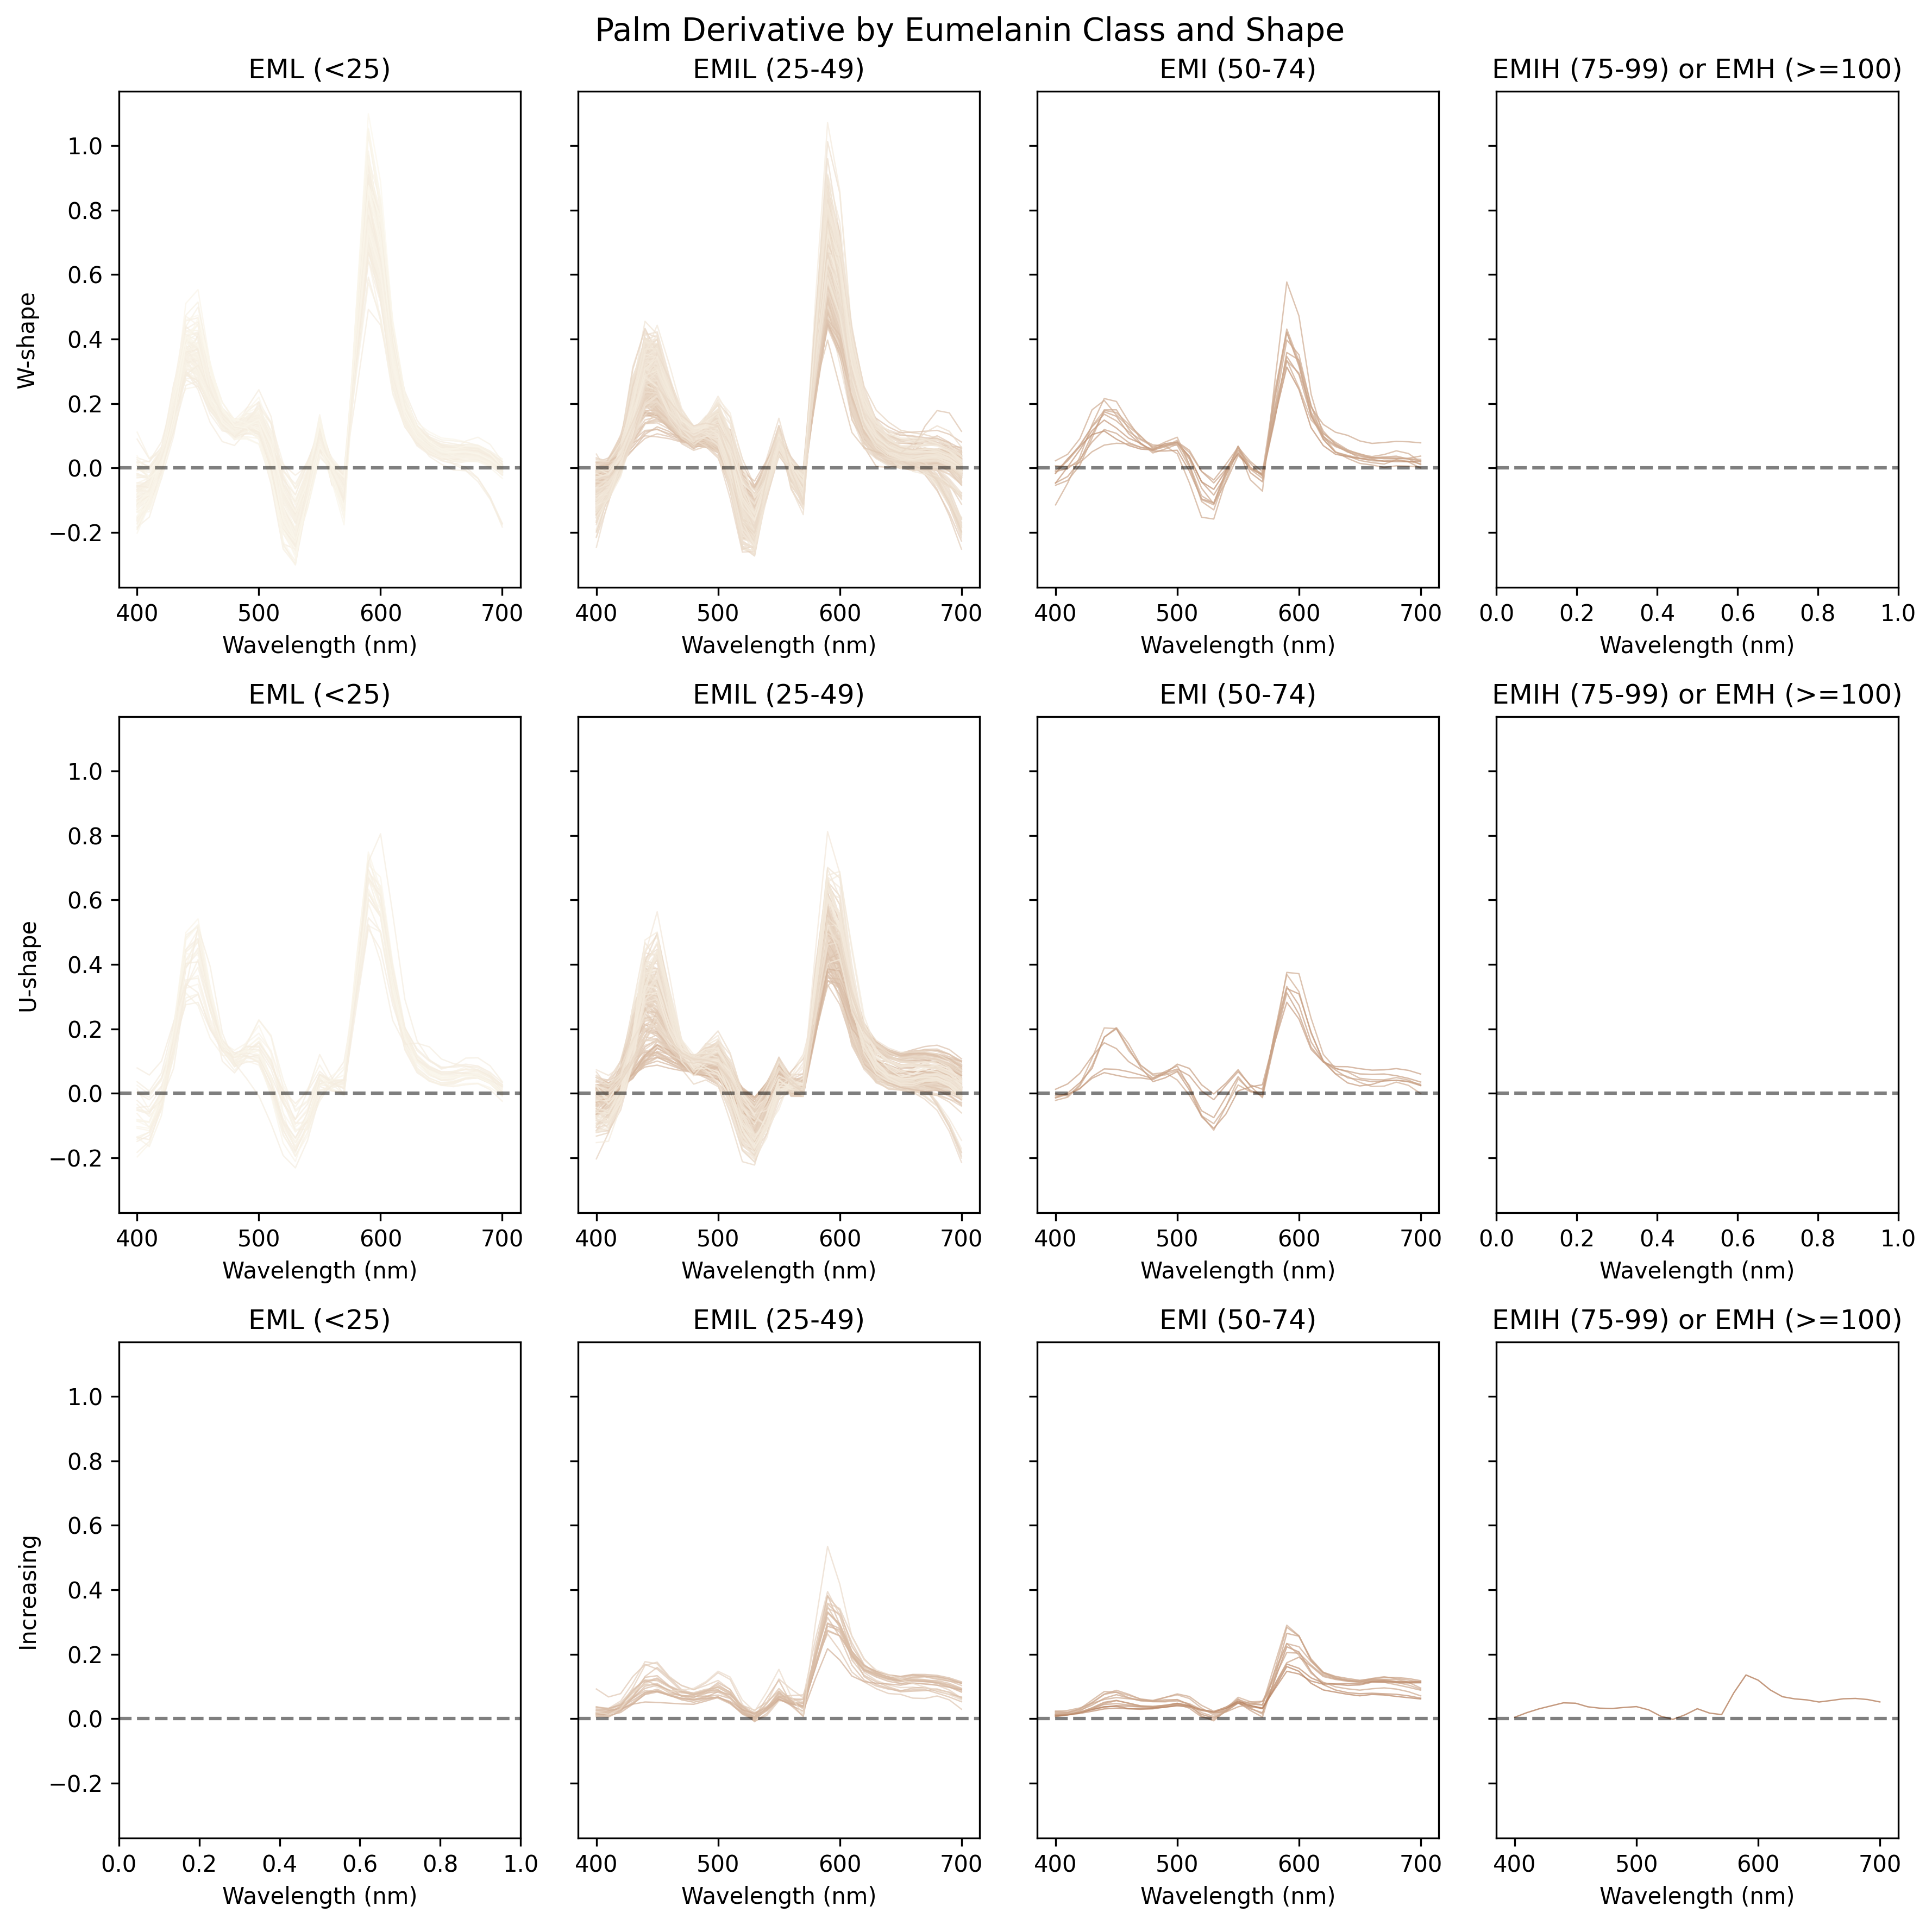

In [49]:
# Visualize the skin reflectance spectra by eumelanin class for each shape category
fitzpatrick = ["#fbf7ec", "#a15c33", "#42230c"]
cmap = LinearSegmentedColormap.from_list("fitzpatrick", fitzpatrick)
norm = plt.Normalize(vmin=20, vmax=150)

fig, axes = plt.subplots(3, 4, figsize=(12, 12), dpi=300, sharey=True)

for i, shape in enumerate(shape_order):
    # Plot ISSA spectra
    ax = axes[i, 0]
    eml_mask = (palm_df['Eumelanin Class'] == 'EML (<25)') & (palm_df['Shape'] == shape)
    eml_indices = palm_df[eml_mask].index
    for j in eml_indices:
        color = cmap(norm(palm_mi[j]))
        ax.plot(issa_wavelengths, palm_drv_clean[j, :], color=color, alpha=0.7, linewidth=0.6)
    ax.set_title('EML (<25)')
    ax.set_ylabel(shape)
    ax.set_xlabel('Wavelength (nm)')
    ax.axhline(0, color='k', linestyle='--', alpha=0.5)

    # Plot ISSA spectra
    ax = axes[i, 1]
    emil_mask = (palm_df['Eumelanin Class'] == 'EMIL (25-49)') & (palm_df['Shape'] == shape)
    emil_indices = palm_df[emil_mask].index
    for j in emil_indices:
        color = cmap(norm(palm_mi[j]))
        ax.plot(issa_wavelengths, palm_drv_clean[j, :], color=color, alpha=0.7, linewidth=0.6)
    ax.set_title('EMIL (25-49)')
    ax.set_xlabel('Wavelength (nm)')
    ax.axhline(0, color='k', linestyle='--', alpha=0.5)

    # Plot ISSA spectra
    ax = axes[i, 2]
    emi_mask = (palm_df['Eumelanin Class'] == 'EMI (50-74)') & (palm_df['Shape'] == shape)
    emi_indices = palm_df[emi_mask].index
    for j in emi_indices:
        color = cmap(norm(palm_mi[j]))
        ax.plot(issa_wavelengths, palm_drv_clean[j, :], color=color, alpha=0.7, linewidth=0.6)
    ax.set_title('EMI (50-74)')
    ax.set_xlabel('Wavelength (nm)')
    ax.axhline(0, color='k', linestyle='--', alpha=0.5)

    # Plot ISSA spectra
    ax = axes[i, 3]
    emh_mask = ((palm_df['Eumelanin Class'] == 'EMIH (75-99)') | (palm_df['Eumelanin Class'] == 'EMH (>=100)')) & (palm_df['Shape'] == shape)
    emh_indices = palm_df[emh_mask].index
    for j in emh_indices:
        color = cmap(norm(palm_mi[j]))
        ax.plot(issa_wavelengths, palm_drv_clean[j, :], color=color, alpha=0.7, linewidth=0.6)
    ax.set_title('EMIH (75-99) or EMH (>=100)')
    ax.set_xlabel('Wavelength (nm)')
    ax.axhline(0, color='k', linestyle='--', alpha=0.5)

plt.suptitle(f'Palm Derivative by Eumelanin Class and Shape', fontsize=14)
plt.tight_layout()
plt.show()

## Key observations

- The skin reflectance spectra of lighter skin tones predominantly exhibit a W-shape or U-shape profile, whereas darker skin tones generally display an increasing shape.

- The proportion of the W-shape decreases as the Melanin Index (MI) rises. In contrast, the proportion of the U-shape peaks within the EMIL class ($25 \leq \mathrm{MI} < 50$), and the increasing shape becomes more dominant at higher MI values.

- Spectral shape distributions vary significantly across different body sites.